# Modellierung mit Prophet — PM2.5 Beijing

**Capstone-Projekt · CRISP-DM Phase 4 (Modeling)**
Bettina Gertjerenken · Kai Steffen

Wir bestimmen zuerst eine **Seasonal-Naive-Baseline** als Messlatte und trainieren dann **Facebook Prophet** in einer aufsteigenden Konfigurations-Leiter — jede Stufe fügt genau **einen** Baustein hinzu, so sieht man dessen Beitrag direkt. Der **Feiertagskalender (CN)** kommt bewusst früh dazu: Kapitel 01 hat gezeigt, dass das Feuerwerk zum chinesischen Neujahr PM2.5 kurzzeitig verzehnfacht.

0. **Seasonal Naive (Baseline)** — muss von jedem echten Modell geschlagen werden,
1. **Basis, univariat** (nur `ds`+`y`) — Referenz,
2. **Basis + Feiertage** (`add_country_holidays("CN")`),
3. **Basis + Feiertage + Wetter-Regressoren**,
4. **Behandelt + Feiertage + Wetter-Regressoren**,
5. **Behandelt + Feiertage + Wetter-Regressoren + Log-Ziel** (gegen die Rechtsschiefe).

Alle Läufe vergleichen wir einheitlich über **MAE**, **RMSE**, **MASE** und **MAPE** — jeweils für das **gesamte Testjahr** und die kurzfristigen Horizonte **8 / 24 / 48 / 72 Stunden**. Danach erweitern wir das Ganze auf **alle 12 Stationen** und zeigen den **Datenverlauf** (echt vs. Vorhersage) im Stadt-Mittel.

> ⚙️ **Kernel:** Umgebung **`ts-tutorial`** wählen (dort ist Prophet installiert).
> 📁 **Voraussetzung:** Kapitel 03 einmal ausführen, damit `../data/prepared/basis/` und `../data/prepared/behandelt/` gefüllt sind.

## 1. Bibliotheken & Prophet-Version

Wir arbeiten mit der in `ts-tutorial` installierten Prophet-Version (**1.3.0**) und nutzen nur die stabile
öffentliche API (`Prophet`, `add_regressor`, `fit`, `predict`, `plot_components`).

In [ ]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import prophet
from prophet import Prophet

print("Prophet-Version:", prophet.__version__)   # sollte 1.3.0 sein

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 60, "axes.titlesize": 13, "axes.titleweight": "bold"})
AMBER, RUST, SLATE, TEAL, MOSS = "#E0912F", "#C4471C", "#3A4148", "#1C7293", "#2C5F2D"
FBBLAU = "#1877F2"   # Facebook-Blau: einheitliche Farbe fuer alle Prophet-Linien

Prophet-Version: 1.3.0


## 2. Konfiguration

Zentrale Einstellungen an einem Ort. `REGRESSOREN` sind die in Kapitel 03 aufbereiteten Wetter- und Windrichtungs-Spalten.

In [ ]:
STATION = "Aotizhongxin"          # Beispielstation fuer die Detail-Analyse
PREP = Path("../data/prepared")

REGRESSOREN = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos"]

# einheitliche Prophet-Grundeinstellung fuer alle Laeufe (fairer Vergleich)
PROPHET_KWARGS = dict(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    changepoint_prior_scale=0.05,
)

## 3. Hilfsfunktionen: Laden & Fehlermaße

Wir bewerten **alle** Vorhersagen (Baseline und Prophet) einheitlich mit vier Fehlermaßen:

| Maß | Idee | Einheit | Aussage |
|---|---|---|---|
| **MAE** | Mittelwert von \|y − ŷ\| | µg/m³ | durchschnittlicher absoluter Fehler; jeder Fehler zählt gleich viel |
| **RMSE** | Wurzel aus dem Mittelwert von (y − ŷ)² | µg/m³ | wie MAE, aber **große Einzelfehler werden durch das Quadrieren stärker bestraft** |
| **MASE** | MAE ÷ MAE der Seasonal-Naive-Vorhersage auf den Trainingsdaten (m = 24 h) | einheitenlos | **< 1 = besser als die naive Baseline**, > 1 = schlechter |
| **MAPE** | Mittelwert von \|y − ŷ\| ⁄ y · 100 | % | „im Schnitt X % daneben“ — anschaulich, aber heikel bei kleinen Messwerten |

**Worin unterscheiden sich die Maße?**

- **MAE vs. RMSE:** Beide messen in µg/m³, aber RMSE quadriert die Fehler vor dem Mitteln. Es gilt immer RMSE ≥ MAE — je größer der Abstand zwischen beiden, desto mehr einzelne **Ausreißer-Fehler** stecken in der Vorhersage. Bei PM2.5 mit seinen Smog-Spitzen ist dieser Vergleich besonders aufschlussreich.
- **MAPE** misst **relativ** statt absolut: 10 µg/m³ Fehler bei einem echten Wert von 20 sind 50 %, bei 200 nur 5 %. Das macht MAPE leicht kommunizierbar — aber bei sehr kleinen echten Werten (saubere Luft, y nahe 0) explodieren die Prozentwerte, MAPE überzeichnet dann.
- **MASE** (*Mean Absolute Scaled Error*, Hyndman & Koehler 2006) löst genau dieses Problem: Statt durch y zu teilen, wird der MAE des Modells durch den MAE der **Seasonal-Naive-Vorhersage** ŷ(t) = y(t − 24 h) **auf den Trainingsdaten** geteilt. MASE ist damit robust gegen Werte nahe 0, einheitenlos über Stationen vergleichbar und direkt interpretierbar: *MASE = 0.8* heißt „20 % besser als die naive Baseline“, *MASE = 1.2* heißt „schlechter als naiv — das Modell lohnt sich nicht“.

In [3]:
def lade(variante, station=STATION):
    """variante = 'basis' oder 'behandelt' -> (train, test)."""
    tr = pd.read_csv(PREP / variante / f"prophet_train_{station}.csv", parse_dates=["ds"])
    te = pd.read_csv(PREP / variante / f"prophet_test_{station}.csv",  parse_dates=["ds"])
    return tr, te


# --- die vier Fehlermaße -----------------------------------------------------
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))              # µg/m³
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat) ** 2)))      # µg/m³
def mape(y, yhat): return float(np.mean(np.abs((y - yhat) / y)) * 100)  # in %

SAISON_M = 24   # Saisonperiode fuer Seasonal Naive & MASE: 24 h (Tagesmuster)

def mase_skala(train_y, m=SAISON_M):
    """Skalierungsfaktor fuer MASE: MAE der Seasonal-Naive-Vorhersage y(t-m)
    auf den TRAININGSdaten. Wird einmal je Station berechnet."""
    a = np.asarray(train_y, dtype=float)
    return float(np.nanmean(np.abs(a[m:] - a[:-m])))

def mase(y, yhat, skala):
    """MASE = MAE des Modells / MAE der naiven Baseline. < 1 = besser als Baseline."""
    return float(mae(y, yhat) / skala)

def jahres_fehler(out, skala):
    """Alle vier Fehlermaße fuer einen Ergebnis-Frame mit Spalten ds, y, yhat."""
    return {"MAE": mae(out["y"], out["yhat"]), "RMSE": rmse(out["y"], out["yhat"]),
            "MASE": mase(out["y"], out["yhat"], skala), "MAPE %": mape(out["y"], out["yhat"])}

## 4. Kernfunktion: trainieren & vorhersagen

**Eine** Funktion für alle Konfigurationen — so bleibt der Vergleich fair. Sie kann:

- beliebige **Regressoren** einbinden (`add_regressor`),
- optional auf dem **Log-Ziel** trainieren (`log=True`): intern `log1p(y)`, am Ende mit `expm1` zurücktransformiert.

So ist die Vorhersage immer in echten µg/m³ — dadurch sind die Fehlermaße über alle Konfigurationen direkt vergleichbar.

> ⚠️ **Wichtig für die Interpretation — die Regressoren enthalten die _echten_ Wetterwerte des Testzeitraums.** In `fit_predict` bekommt Prophet über `fut = test[["ds"] + regressoren]` die tatsächlich gemessenen Temperatur-, Wind- und Feuchtewerte der Zukunft. In einer realen Prognose kennt man diese nicht — man hätte nur eine **Wettervorhersage**. Die sehr guten Kurzfrist-Fehler der Regressor-Konfigurationen entstehen also teilweise dadurch, dass das Modell das echte Zukunftswetter „kennt". Das ist für eine *Wirkungsanalyse* der Regressoren legitim, überschätzt aber die operative Prognosegüte. **Konsequenz für den späteren Chronos-Vergleich:** Chronos muss dieselben Zukunfts-Regressoren als Covariates bekommen, sonst vergleicht man ungleiche Informationsstände.

In [4]:
def fit_predict(train, test, regressoren=None, log=False, feiertage=None, prophet_kwargs=None):
    regressoren = regressoren or []
    prophet_kwargs = prophet_kwargs or PROPHET_KWARGS   # Standard, oder eigene Werte (Tuning)

    # Trainingsframe im Prophet-Format (ds, y[, Regressoren]) bauen
    tr = pd.DataFrame({"ds": train["ds"].values})
    tr["y"] = np.log1p(train["y"].values) if log else train["y"].values
    for r in regressoren:
        tr[r] = train[r].values

    m = Prophet(**prophet_kwargs)
    if feiertage:
        m.add_country_holidays(country_name=feiertage)   # z.B. "CN" = China
    for r in regressoren:
        m.add_regressor(r)
    m.fit(tr)

    fut = test[["ds"] + regressoren].copy()      # Regressoren muessen im Test vorliegen
    fc = m.predict(fut)

    # ggf. zuruecktransformieren (log -> µg/m³)
    rueck = (lambda a: np.expm1(a)) if log else (lambda a: a)
    out = test[["ds", "y"]].merge(fc[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        out[c] = rueck(out[c]).clip(lower=0)      # PM2.5 >= 0
    return m, fc, out

## 5. Plot-Funktionen

In [5]:
def plot_forecast(out, titel, farbe=FBBLAU, tage=1):
    g = out.set_index("ds").resample(f"{tage}D").mean()
    plt.figure(figsize=(12, 4))
    plt.fill_between(g.index, g["yhat_lower"], g["yhat_upper"], color=farbe, alpha=0.18, label="Unsicherheit")
    plt.plot(g.index, g["y"], color=SLATE, lw=1.4, label="echte Werte")
    plt.plot(g.index, g["yhat"], color=farbe, lw=1.6, label="Vorhersage")
    plt.ylabel("PM2.5 (µg/m³)"); plt.title(titel); plt.legend(loc="best"); plt.tight_layout(); plt.show()


def plot_scatter(out, titel, farbe=FBBLAU):
    plt.figure(figsize=(4.6, 4.6))
    plt.scatter(out["y"], out["yhat"], s=4, alpha=0.2, color=farbe)
    lim = max(out["y"].max(), out["yhat"].max())
    plt.plot([0, lim], [0, lim], color=RUST, lw=1.2, ls="--", label="perfekt")
    plt.xlabel("echte PM2.5"); plt.ylabel("Vorhersage"); plt.title(titel); plt.legend(loc="best")
    plt.tight_layout(); plt.show()

### Kurzfrist-Helfer: 8 / 24 / 48 / 72 Stunden + ganzes Jahr

Drei Funktionen für die Prognosegüte nach Horizont: eine Fehlertabelle je Horizont (inklusive gesamtem Testjahr), eine Ergebniszeile für den späteren Stations-Sweep und eine stündliche Grafik der ersten 8/24/48/72 h. Alle geben immer **alle vier Fehlermaße** (MAE, RMSE, MASE, MAPE) aus.

In [6]:
HORIZONTE = [8, 24, 48, 72]   # kurzfristige Prognose-Zeitraeume in Stunden


def fehler_horizonte(out, skala, horizonte=HORIZONTE):
    """MAE/RMSE/MASE/MAPE fuer die ersten N Stunden des Testzeitraums + das gesamte Testjahr."""
    o = out.sort_values("ds").reset_index(drop=True)
    zeilen = []
    for h in list(horizonte) + [len(o)]:
        w = o.iloc[:h]
        name = f"{h} h" if h < len(o) else "ganzes Jahr"
        zeilen.append({"Horizont": name, "MAE": mae(w["y"], w["yhat"]),
                       "RMSE": rmse(w["y"], w["yhat"]),
                       "MASE": mase(w["y"], w["yhat"], skala),
                       "MAPE %": mape(w["y"], w["yhat"])})
    return pd.DataFrame(zeilen)


def sweep_zeile(out, skala, horizonte=HORIZONTE):
    """Eine Ergebniszeile fuer den Stations-Sweep: Jahresfehler + alle Horizont-Fehler."""
    row = jahres_fehler(out, skala)
    o = out.sort_values("ds").reset_index(drop=True)
    for h in horizonte:
        w = o.iloc[:h]
        row[f"MAE_{h}h"]  = mae(w["y"], w["yhat"])
        row[f"RMSE_{h}h"] = rmse(w["y"], w["yhat"])
        row[f"MASE_{h}h"] = mase(w["y"], w["yhat"], skala)
        row[f"MAPE_{h}h"] = mape(w["y"], w["yhat"])
    return row


def plot_horizonte(out, titel, skala, farbe=FBBLAU, horizonte=HORIZONTE):
    """Stuendliche Ansicht der ersten 8/24/48/72 h: echt vs. Vorhersage, Fehler im Titel."""
    o = out.sort_values("ds").reset_index(drop=True)
    fig, axes = plt.subplots(len(horizonte), 1, figsize=(12, 3.0*len(horizonte)))
    for ax, h in zip(np.atleast_1d(axes), horizonte):
        w = o.iloc[:h]
        ax.fill_between(w["ds"], w["yhat_lower"], w["yhat_upper"], color=farbe, alpha=0.18)
        ax.plot(w["ds"], w["y"], color=SLATE, lw=1.5, marker="o", ms=3, label="echt")
        ax.plot(w["ds"], w["yhat"], color=farbe, lw=1.8, marker="o", ms=3, label="Vorhersage")
        ax.set_title(f"{titel} - erste {h} h  (MAE {mae(w['y'],w['yhat']):.1f}, RMSE {rmse(w['y'],w['yhat']):.1f}, "
                     f"MASE {mase(w['y'],w['yhat'],skala):.2f}, MAPE {mape(w['y'],w['yhat']):.0f}%)")
        ax.set_ylabel("PM2.5"); ax.legend(loc="best")
    plt.tight_layout(); plt.show()

## 6. Baseline: Seasonal Naive — bevor Prophet läuft

Bevor ein „richtiges“ Modell antritt, brauchen wir eine **Baseline**: eine bewusst simple Vorhersage als Messlatte. Erst wenn Prophet diese Messlatte schlägt, lohnt sich der ganze Aufwand. Wir rechnen **zwei Varianten**:

**Variante 1 — letzter Trainingstag (m = 24 h), unsere Haupt-Baseline:**

> **ŷ(t) = y(t − 24 h)**

Die Vorhersage für eine Stunde ist der **echte Wert derselben Stunde einen Tag zuvor**. Ab Testbeginn (**1.3.2016**) kennen wir aber keine echten Werte mehr — deshalb nehmen wir das Tagesprofil des **letzten Trainingstages (29.2.2016)** und wiederholen es für das gesamte Testjahr: Die Vorhersage für 14:00 Uhr ist an *jedem* Testtag der Trainingswert vom 29.2.2016, 14:00 Uhr. Für Stundendaten ist m = 24 die Standard-Saisonperiode (Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*) — und dieselbe Rechnung auf den **Trainingsdaten** liefert den **MASE-Skalierungsfaktor**. Genau deshalb bedeutet MASE < 1 „besser als Seasonal Naive“.

**Variante 2 — gleiche Stunde im Vorjahr (m = 365 · 24 h):**

> **ŷ(t) = y(t − 1 Jahr)**

Die Vorhersage ist der Trainingswert **derselben Stunde ein Jahr zuvor** (März 2015 – Februar 2016). Diese Variante kennt die **Jahressaisonalität** (Wintersmog!), die Variante 1 komplett fehlt — klingt also erst einmal klüger.

**Was zeigt der Vergleich?** Übers ganze Testjahr schneidet das Vorjahresprofil trotzdem meist **schlechter** ab: PM2.5 ist stark wettergetrieben, die konkreten Tageswerte wiederholen sich von Jahr zu Jahr kaum. Das Vorjahresprofil hat zwar die richtige Saisonform, aber seine Werte sind mit dem Testjahr fast unkorreliert — und eine unkorrelierte Vorhersage mit voller Streuung erzeugt mehr Fehler als ein „langweiliges“ konstantes Profil auf mittlerem Niveau. Eine gute Lektion: **Mehr eingebautes Wissen macht eine Baseline nicht automatisch besser.**

Die Fehlermaße berechnen wir für beide Varianten fürs **gesamte Testjahr** und die Horizonte **8 / 24 / 48 / 72 h** — mit exakt derselben Logik wie später bei Prophet, damit der Vergleich fair ist.

In [7]:
def seasonal_naive(train, test, m=SAISON_M):
    """Variante 1: Tagesprofil des letzten Trainingstages,
    wiederholt ueber den gesamten Testzeitraum."""
    profil = (train.sort_values("ds").tail(m)               # letzte 24 h des Trainings
                    .assign(stunde=lambda d: d["ds"].dt.hour)
                    .set_index("stunde")["y"])
    out = test[["ds", "y"]].copy()
    out["yhat"] = profil.loc[out["ds"].dt.hour].to_numpy()  # gleiche Stunde -> gleicher Wert
    out["yhat_lower"] = out["yhat_upper"] = out["yhat"]     # Baseline hat keine Unsicherheitsbaender
    return out


def seasonal_naive_vorjahr(train, test, stunden=365*24):
    """Variante 2: Wert derselben Stunde ein Jahr zuvor (aus den Trainingsdaten)."""
    lookup = train.set_index("ds")["y"]
    out = test[["ds", "y"]].copy()
    out["yhat"] = lookup.reindex(out["ds"] - pd.Timedelta(hours=stunden)).to_numpy()
    out["yhat_lower"] = out["yhat_upper"] = out["yhat"]
    return out


tr_basis, te_basis = lade("basis")
SKALA = mase_skala(tr_basis["y"])            # MASE-Skala der Station (Training, m=24)
baseline_out  = seasonal_naive(tr_basis, te_basis)          # Variante 1 (Haupt-Baseline)
baseline_vj_out = seasonal_naive_vorjahr(tr_basis, te_basis) # Variante 2 (Vorjahr)

print(f"Station: {STATION}")
print(f"Vorhersage ab {baseline_out['ds'].min():%d.%m.%Y %H:%M} bis {baseline_out['ds'].max():%d.%m.%Y %H:%M}")
print(f"MASE-Skala (Training, m=24): {SKALA:.2f} µg/m³")
print()
print("Variante 1 - Seasonal Naive, letzter Trainingstag (m=24):")
print(fehler_horizonte(baseline_out, SKALA).to_string(index=False))
print()
print("Variante 2 - Seasonal Naive, gleiche Stunde im Vorjahr:")
print(fehler_horizonte(baseline_vj_out, SKALA).to_string(index=False))

Station: Aotizhongxin
Vorhersage ab 01.03.2016 00:00 bis 28.02.2017 23:00
MASE-Skala (Training, m=24): 59.23 µg/m³

Variante 1 - Seasonal Naive, letzter Trainingstag (m=24):
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  86.750000  88.659461 1.464563  88.203052
       24 h  92.500000  95.973521 1.561637  75.174069
       48 h 114.895833 125.721501 1.939736  75.803754
       72 h 166.763889 188.372230 2.815402  80.552856
ganzes Jahr  63.585869  98.547642 1.073493 120.621261

Variante 2 - Seasonal Naive, gleiche Stunde im Vorjahr:
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  32.250000  36.231892 0.544463  31.204750
       24 h  73.375000  91.196039 1.238758  53.590357
       48 h 116.895833 133.990922 1.973502  73.630382
       72 h 171.041667 196.958302 2.887622  79.888380
ganzes Jahr  73.138309 107.526122 1.234762 239.248257


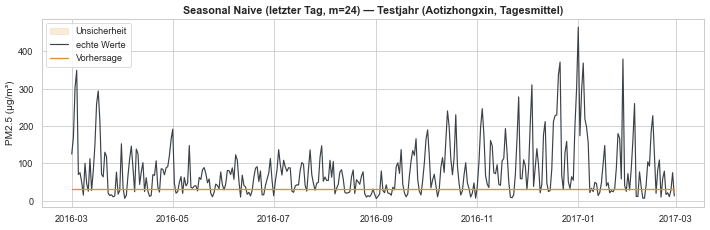

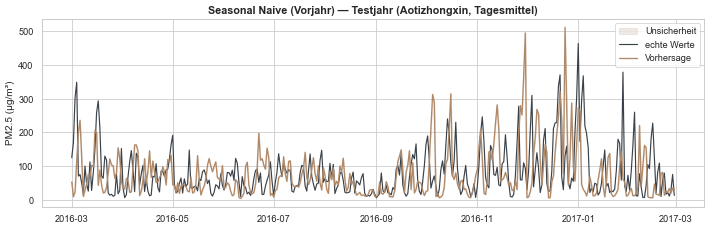

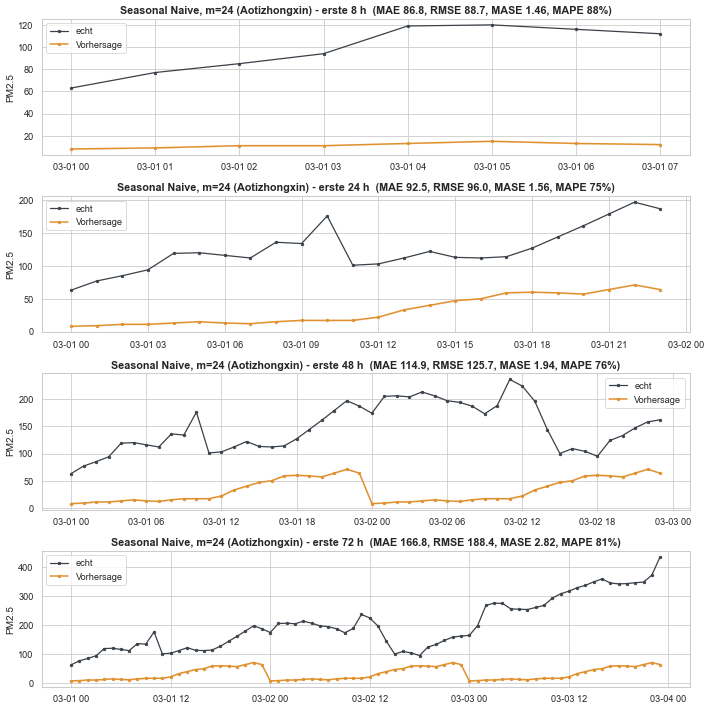

In [8]:
plot_forecast(baseline_out,    f"Seasonal Naive (letzter Tag, m=24) — Testjahr ({STATION}, Tagesmittel)", farbe=AMBER)
plot_forecast(baseline_vj_out, f"Seasonal Naive (Vorjahr) — Testjahr ({STATION}, Tagesmittel)", farbe="#B08968")
plot_horizonte(baseline_out, f"Seasonal Naive, m=24 ({STATION})", SKALA, farbe=AMBER)

## 7. Detail-Analyse für eine Station: Baseline + 5 Prophet-Stufen

Wir lassen für `STATION` die komplette Konfigurations-Leiter laufen und vergleichen sie — zusammen mit den beiden Seasonal-Naive-Baselines aus Abschnitt 6 — über alle vier Fehlermaße.

**Warum Feiertage schon als Stufe 2?** Rund um das **Frühlingsfest** ändern sich Verkehr, Industrie und vor allem das **Feuerwerk** — Kapitel 01 (Abschnitt 8) zeigt Peaks bis fast 700 µg/m³ in den ersten Neujahrsstunden. Das ist ein reiner Kalender-Effekt, den Prophet über `add_country_holidays("CN")` lernen *könnte* — deshalb testen wir ihn als eigene Stufe, noch bevor Wetter-Regressoren ins Spiel kommen.

> ⚠️ **Was die Ergebnisse tatsächlich zeigen (Spoiler):** Die Feiertage **allein** verbessern das Modell **nicht** — in der Tabelle unten liegt „Basis + Feiertage" sogar minimal *schlechter* als „Basis (univariat)". Der Grund: Das Trainingsfenster enthält nur wenige Neujahrs-Feste, das reicht Prophet nicht, um einen stabilen, verallgemeinerbaren Feiertagseffekt zu schätzen; über das ganze Testjahr überwiegt das Rauschen. Der große Sprung kommt erst durch die **Wetter-Regressoren** und die **behandelten Daten**. Ein ehrliches, lehrreiches Ergebnis: *eingebautes Fachwissen hilft nur, wenn genug Daten den Effekt tragen.*

> 🔍 **Hinweis zur Stufe Behandelt (inzwischen korrigiert):** Die behandelte Variante kappt Ausreißer auf das 99,9-Perzentil des Trainings — aber **nur im Training**; die **Test-Zielwerte bleiben echt** (Notebook 02, Abschnitt 10). Das Entkappen der Testwerte hat den Fehler nur **minimal** verändert (Stationsmittel-RMSE 74,1 -> 74,6; MASE unverändert 0,84). Der Sprung von Basis+Reg (RMSE 90,9) auf Behandelt+Reg (74,6) ist damit ein **echter** Modellgewinn durch sauberere Trainingsdaten — kein Artefakt eines leichteren Ziels.

> ⏱️ **Laufzeit:** Jeder Fit auf ~26.000 Stundenwerten dauert **~10–30 Sekunden**, die fünf Läufe zusammen ca. **1–3 Minuten**. Die Baselines kosten praktisch keine Rechenzeit.

In [9]:
# Konfigurations-Leiter: jede Stufe fuegt genau einen Baustein hinzu
konfigs = {
    "Basis (univariat)":                   dict(variante="basis",     regressoren=[],          log=False),
    "Basis + Feiertage":                   dict(variante="basis",     regressoren=[],          log=False, feiertage="CN"),
    "Basis + Feiertage + Regressoren":     dict(variante="basis",     regressoren=REGRESSOREN, log=False, feiertage="CN"),
    "Behandelt + Feiertage + Regressoren": dict(variante="behandelt", regressoren=REGRESSOREN, log=False, feiertage="CN"),
    "Behandelt + FT + Reg + Log":          dict(variante="behandelt", regressoren=REGRESSOREN, log=True,  feiertage="CN"),
}

# Die beiden Baselines aus Abschnitt 6 laufen als Referenz in der Tabelle mit
modelle = {}
ergebnisse = {"Seasonal Naive (Baseline)": baseline_out,
              "Seasonal Naive (Vorjahr)":  baseline_vj_out}
zeilen = [{"Konfiguration": "Seasonal Naive (Baseline)", **jahres_fehler(baseline_out, SKALA)},
          {"Konfiguration": "Seasonal Naive (Vorjahr)",  **jahres_fehler(baseline_vj_out, SKALA)}]

for name, cfg in konfigs.items():
    tr, te = lade(cfg["variante"])
    m, fc, out = fit_predict(tr, te, regressoren=cfg["regressoren"], log=cfg["log"],
                             feiertage=cfg.get("feiertage"))
    modelle[name], ergebnisse[name] = (m, fc), out
    zeilen.append({"Konfiguration": name, **jahres_fehler(out, SKALA)})
    print(f"fertig: {name}")

metriken = pd.DataFrame(zeilen)
print(); print(metriken.to_string(index=False))

17:38:53 - cmdstanpy - INFO - Chain [1] start processing
17:39:01 - cmdstanpy - INFO - Chain [1] done processing


fertig: Basis (univariat)


17:39:03 - cmdstanpy - INFO - Chain [1] start processing
17:39:18 - cmdstanpy - INFO - Chain [1] done processing


fertig: Basis + Feiertage


17:39:21 - cmdstanpy - INFO - Chain [1] start processing
17:39:40 - cmdstanpy - INFO - Chain [1] done processing


fertig: Basis + Feiertage + Regressoren


17:39:43 - cmdstanpy - INFO - Chain [1] start processing
17:39:54 - cmdstanpy - INFO - Chain [1] done processing


fertig: Behandelt + Feiertage + Regressoren


17:39:57 - cmdstanpy - INFO - Chain [1] start processing
17:40:08 - cmdstanpy - INFO - Chain [1] done processing


fertig: Behandelt + FT + Reg + Log

                      Konfiguration       MAE       RMSE     MASE     MAPE %
          Seasonal Naive (Baseline) 63.585869  98.547642 1.073493 120.621261
           Seasonal Naive (Vorjahr) 73.138309 107.526122 1.234762 239.248257
                  Basis (univariat) 78.825579 114.018084 1.330778  97.473757
                  Basis + Feiertage 79.710637 115.218391 1.345720  98.933767
    Basis + Feiertage + Regressoren 62.210876  89.936241 1.050279  87.642021
Behandelt + Feiertage + Regressoren 40.292994  62.431793 0.680249 105.738959
         Behandelt + FT + Reg + Log 39.637434  66.781352 0.669182  68.691556


**Fehlermaße im Vergleich** (kleiner = besser; bei MASE markiert die gestrichelte Linie 1.0 das Niveau der Baseline — nur darunter lohnt sich ein Modell):

> 📌 **So liest man die Balken — Nutzen in der richtigen Reihenfolge:** **Feiertage** verschieben kaum etwas (teils leicht schlechter), die **Wetter-Regressoren** bringen den ersten großen Sprung, die **behandelten Daten** den zweiten (teils durch das leichtere Ziel, siehe Hinweis oben), das **Log-Ziel** senkt vor allem den MAPE. Erst ab „Basis + Feiertage + Regressoren" fällt MASE unter 1 — ab da schlägt das Modell die naive Baseline übers ganze Jahr.

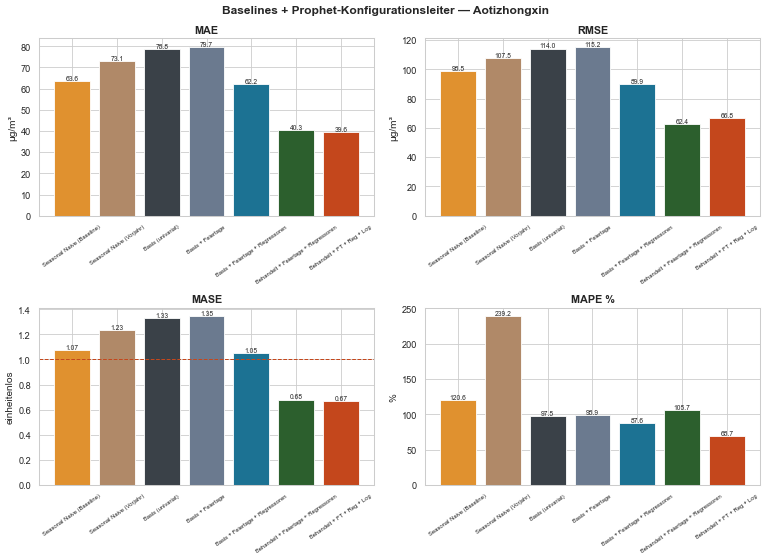

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
farben = [AMBER, "#B08968", SLATE, "#6B7A8F", TEAL, MOSS, RUST][:len(metriken)]
einheiten = {"MAE": "µg/m³", "RMSE": "µg/m³", "MASE": "einheitenlos", "MAPE %": "%"}

for ax, metrik in zip(axes.ravel(), ["MAE", "RMSE", "MASE", "MAPE %"]):
    bars = ax.bar(metriken["Konfiguration"], metriken[metrik], color=farben)
    ax.set_title(metrik); ax.set_ylabel(einheiten[metrik])
    ax.tick_params(axis="x", rotation=35, labelsize=7)
    fmt = "{:.2f}" if metrik == "MASE" else "{:.1f}"
    for b, v in zip(bars, metriken[metrik]):
        ax.text(b.get_x()+b.get_width()/2, v, fmt.format(v), ha="center", va="bottom", fontsize=8)
    if metrik == "MASE":
        ax.axhline(1.0, color=RUST, lw=1.2, ls="--")   # 1.0 = Niveau der Baseline

plt.suptitle(f"Baselines + Prophet-Konfigurationsleiter — {STATION}", fontweight="bold")
plt.tight_layout(); plt.show()

**Vorhersage vs. echte Werte** für die beste Prophet-Konfiguration (nach RMSE):

Beste Prophet-Konfiguration nach RMSE: Behandelt + Feiertage + Regressoren


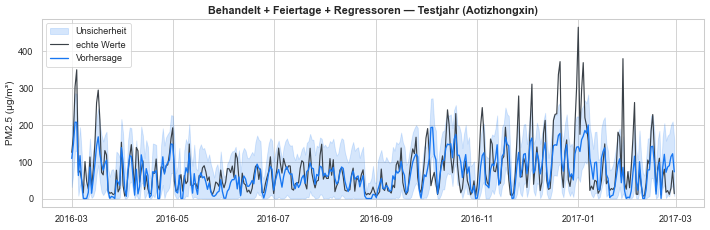

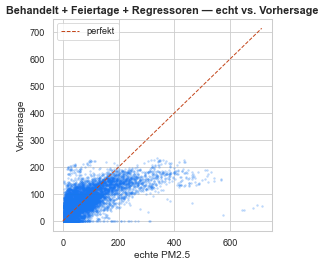

In [11]:
baseline_namen = ["Seasonal Naive (Baseline)", "Seasonal Naive (Vorjahr)"]
prophet_only = metriken[~metriken["Konfiguration"].isin(baseline_namen)]
bestname = prophet_only.sort_values("RMSE").iloc[0]["Konfiguration"]
print("Beste Prophet-Konfiguration nach RMSE:", bestname)
plot_forecast(ergebnisse[bestname], f"{bestname} — Testjahr ({STATION})")
plot_scatter(ergebnisse[bestname], f"{bestname} — echt vs. Vorhersage")

**Prophet-Komponenten** der besten Konfiguration (Trend, Jahres-, Wochen-, Tagesmuster).

> Hinweis: Wenn die beste Konfiguration das **Log-Ziel** nutzt, sind diese Komponenten auf der **log-Skala** dargestellt.

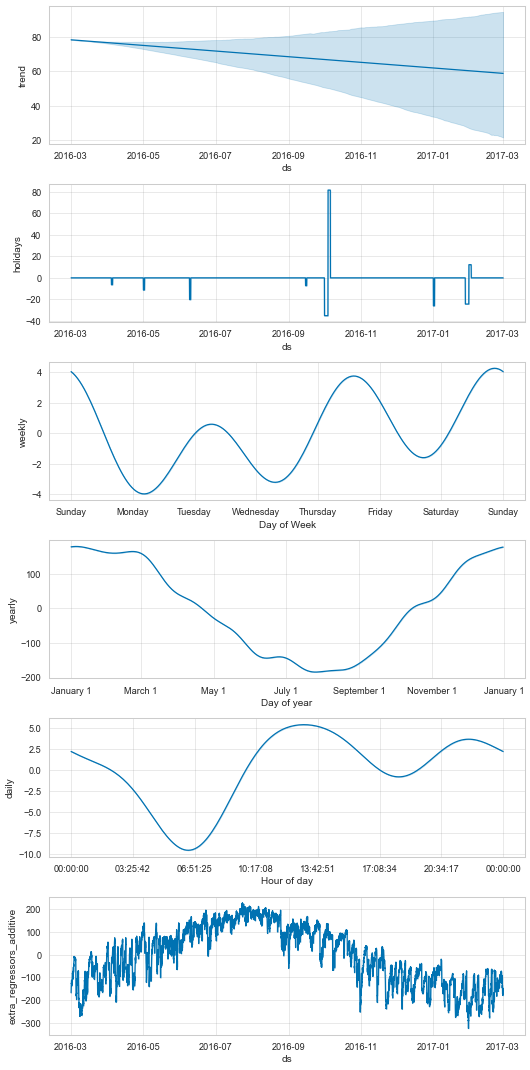

In [12]:
m_best, fc_best = modelle[bestname]
fig = m_best.plot_components(fc_best); plt.show()

### Kurzfristige Prognose: 8 / 24 / 48 / 72 Stunden (stündliche Auflösung)

Für die Praxis zählt oft die **kurzfristige** Güte. Wir zeigen die ersten 8, 24, 48 und 72 Stunden des Testzeitraums
in **stündlicher** Auflösung (nicht geglättet), berechnen die Fehler je Zeitfenster und stellen sie der Baseline gegenüber.

> ⚠️ **Diese Zahlen sind _ein einziger_ Startpunkt (1.3.2016) — nicht repräsentativ.** Die hier sichtbaren Traum-Werte (8-h-MASE ≈ 0,18) entstehen, weil der 1.3.2016 zufällig eine „leichte" Wetterlage war. Wie gut das Modell *im Schnitt* kurzfristig ist, zeigt erst das **rollierende Backtesting in Abschnitt 10** über viele Startpunkte quer durchs Jahr — dort liegt der 8-h-MASE bei **≈ 1,0**, also praktisch auf Baseline-Niveau. **Für die Präsentation die rollierenden Zahlen als Kernaussage nehmen, nicht diese hier.**

Kurzfrist-Fehler - Behandelt + Feiertage + Regressoren (Aotizhongxin):
   Horizont       MAE      RMSE     MASE     MAPE %
        8 h 10.375328 11.323417 0.175162  10.801635
       24 h 22.464919 29.901503 0.379265  15.935580
       48 h 33.310019 40.118755 0.562359  20.987611
       72 h 54.302776 68.466078 0.916770  24.102042
ganzes Jahr 40.292994 62.431793 0.680249 105.738959

Zum Vergleich - Seasonal Naive (Baseline, m=24):
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  86.750000  88.659461 1.464563  88.203052
       24 h  92.500000  95.973521 1.561637  75.174069
       48 h 114.895833 125.721501 1.939736  75.803754
       72 h 166.763889 188.372230 2.815402  80.552856
ganzes Jahr  63.585869  98.547642 1.073493 120.621261

Zum Vergleich - Seasonal Naive (Vorjahr):
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  32.250000  36.231892 0.544463  31.204750
       24 h  73.375000  91.196039 1.238758  53.590357
       48 h 116.895833 133.990922 1.97

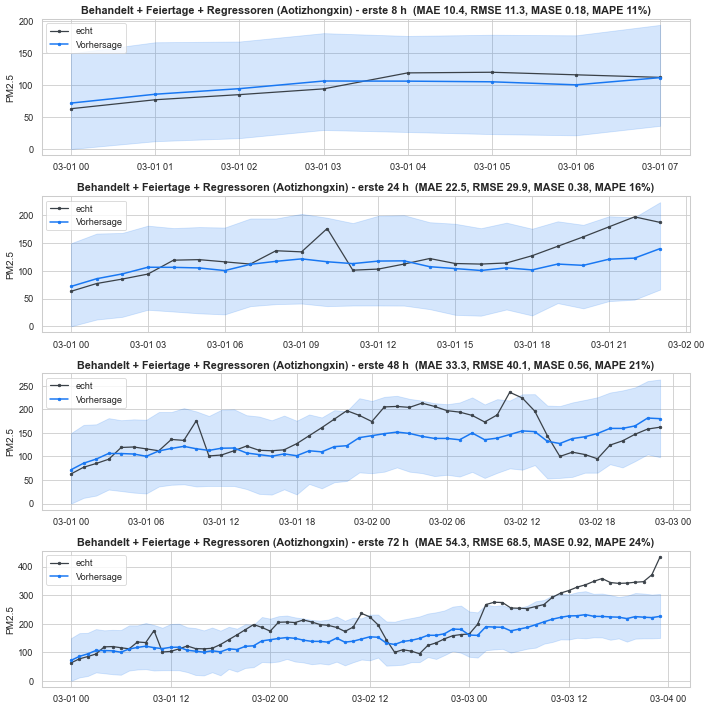

In [13]:
print(f"Kurzfrist-Fehler - {bestname} ({STATION}):")
print(fehler_horizonte(ergebnisse[bestname], SKALA).to_string(index=False))
print()
print("Zum Vergleich - Seasonal Naive (Baseline, m=24):")
print(fehler_horizonte(baseline_out, SKALA).to_string(index=False))
print()
print("Zum Vergleich - Seasonal Naive (Vorjahr):")
print(fehler_horizonte(baseline_vj_out, SKALA).to_string(index=False))

plot_horizonte(ergebnisse[bestname], f"{bestname} ({STATION})", SKALA)

## 8. Erweiterung auf alle 12 Stationen

Jetzt lassen wir die **komplette Leiter** über **alle Stationen** laufen und mitteln die Fehlermaße: die beiden Seasonal-Naive-Baselines plus alle fünf Prophet-Stufen.
Für jede Station und Konfiguration werden alle vier Fehlermaße gespeichert — fürs ganze Testjahr und je Horizont (8/24/48/72 h). Zusätzlich sammeln wir die **Vorhersage-Verläufe** je Station, um sie anschließend im Stadt-Mittel darzustellen.

> ⏱️ **Laufzeit:** 12 Stationen × 5 Prophet-Konfigurationen = **60 Fits** → grob **15–30 Minuten** (die Baselines rechnen in Sekunden).
Zum Ausprobieren erst mit `SCHNELLTEST = True` (nur 2 Stationen) starten!

In [14]:
import time

SCHNELLTEST = False    # False = alle 12 Stationen (voller Lauf); True = nur die ersten 2 (schnell testen)

# dieselbe Konfigurations-Leiter wie in Abschnitt 7
sweep_konfigs = {
    "Basis (univariat)":                   dict(variante="basis",     regressoren=[],          log=False),
    "Basis + Feiertage":                   dict(variante="basis",     regressoren=[],          log=False, feiertage="CN"),
    "Basis + Feiertage + Regressoren":     dict(variante="basis",     regressoren=REGRESSOREN, log=False, feiertage="CN"),
    "Behandelt + Feiertage + Regressoren": dict(variante="behandelt", regressoren=REGRESSOREN, log=False, feiertage="CN"),
    "Behandelt + FT + Reg + Log":          dict(variante="behandelt", regressoren=REGRESSOREN, log=True,  feiertage="CN"),
}
BASELINE_NAMEN = ["Seasonal Naive (Baseline)", "Seasonal Naive (Vorjahr)"]
REIHENFOLGE = BASELINE_NAMEN + list(sweep_konfigs)
SWEEP_FARBEN = [AMBER, "#B08968", SLATE, "#6B7A8F", TEAL, MOSS, RUST]

stationen = sorted(p.name.replace("prophet_train_", "").replace(".csv", "")
                   for p in (PREP / "basis").glob("prophet_train_*.csv"))
if SCHNELLTEST:
    stationen = stationen[:2]
print(f"{len(stationen)} Station(en): {stationen}")

resultate = []
verlaeufe = {name: [] for name in sweep_konfigs}   # Vorhersage-Verlaeufe je Konfiguration sammeln
for st in stationen:
    tr_b, te_b = lade("basis", station=st)
    skala_st = mase_skala(tr_b["y"])                 # MASE-Skala je Station

    # 1) Baselines: Seasonal Naive in beiden Varianten (rechnen in < 1 s)
    resultate.append({"Station": st, "Konfiguration": "Seasonal Naive (Baseline)",
                      **sweep_zeile(seasonal_naive(tr_b, te_b), skala_st)})
    resultate.append({"Station": st, "Konfiguration": "Seasonal Naive (Vorjahr)",
                      **sweep_zeile(seasonal_naive_vorjahr(tr_b, te_b), skala_st)})

    # 2) Prophet-Konfigurationsleiter
    for name, cfg in sweep_konfigs.items():
        t0 = time.time()
        tr, te = lade(cfg["variante"], station=st)
        _, _, out = fit_predict(tr, te, regressoren=cfg["regressoren"], log=cfg["log"],
                                feiertage=cfg.get("feiertage"))
        resultate.append({"Station": st, "Konfiguration": name, **sweep_zeile(out, skala_st)})
        verlaeufe[name].append(out[["ds", "y", "yhat", "yhat_lower", "yhat_upper"]].assign(Station=st))
        print(f"  {st:14s} | {name:36s} | {time.time()-t0:5.0f}s")

ergebnis_alle = pd.DataFrame(resultate)
ergebnis_alle.to_csv("../data/prophet_ergebnisse_stationen.csv", index=False)
print("\ngespeichert: ../data/prophet_ergebnisse_stationen.csv")

12 Station(en): ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


17:40:12 - cmdstanpy - INFO - Chain [1] start processing
17:40:18 - cmdstanpy - INFO - Chain [1] done processing


  Aotizhongxin   | Basis (univariat)                    |     8s


17:40:20 - cmdstanpy - INFO - Chain [1] start processing
17:40:35 - cmdstanpy - INFO - Chain [1] done processing


  Aotizhongxin   | Basis + Feiertage                    |    18s


...

  Wanshouxigong  | Basis + Feiertage + Regressoren      |    29s


17:56:30 - cmdstanpy - INFO - Chain [1] start processing
17:56:50 - cmdstanpy - INFO - Chain [1] done processing


  Wanshouxigong  | Behandelt + Feiertage + Regressoren  |    23s


17:56:53 - cmdstanpy - INFO - Chain [1] start processing
17:57:15 - cmdstanpy - INFO - Chain [1] done processing


  Wanshouxigong  | Behandelt + FT + Reg + Log           |    25s

gespeichert: ../data/prophet_ergebnisse_stationen.csv


**Fehlermaße je Station** (alle sieben Konfigurationen nebeneinander):

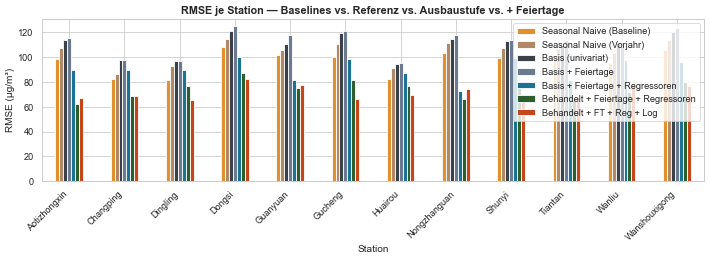

In [15]:
pivot = ergebnis_alle.pivot(index="Station", columns="Konfiguration", values="RMSE")[REIHENFOLGE]
pivot.plot(kind="bar", figsize=(12, 4.5), color=SWEEP_FARBEN)
plt.ylabel("RMSE (µg/m³)"); plt.title("RMSE je Station — Baselines vs. Referenz vs. Ausbaustufe vs. + Feiertage")
plt.xticks(rotation=45, ha="right"); plt.legend(title="", loc="best"); plt.tight_layout(); plt.show()

**Durchschnitt über alle gerechneten Stationen** (alle vier Fehlermaße, ganzes Testjahr):

In [16]:
zusammen = (ergebnis_alle.groupby("Konfiguration")[["MAE", "RMSE", "MASE", "MAPE %"]]
            .mean().round(2).reindex(REIHENFOLGE))
print(zusammen.to_string())

                                       MAE    RMSE  MASE  MAPE %
Konfiguration                                                   
Seasonal Naive (Baseline)            62.03   96.36  1.06  122.07
Seasonal Naive (Vorjahr)             70.88  104.20  1.21  246.65
Basis (univariat)                    75.85  110.24  1.29   97.75
Basis + Feiertage                    77.44  112.36  1.32   99.10
Basis + Feiertage + Regressoren      61.86   90.32  1.06   90.02
Behandelt + Feiertage + Regressoren  48.76   74.30  0.84   86.94
Behandelt + FT + Reg + Log           42.87   72.04  0.73   65.28


**Fehler nach Horizont** (Mittel über alle Stationen):

Zeigt, wie der Fehler mit dem Vorhersage-Horizont wächst — von 8 h über 24/48/72 h bis zum ganzen Testjahr.
Links RMSE (absolut, in µg/m³), rechts MASE (relativ zur Baseline; unter der gestrichelten 1.0-Linie ist ein Modell besser als Seasonal Naive).

RMSE nach Horizont (Mittel ueber alle Stationen):
                                       8 h   24 h    48 h    72 h  ganzes Jahr
Konfiguration                                                                 
Seasonal Naive (Baseline)            79.87  84.92  114.18  170.17        96.36
Seasonal Naive (Vorjahr)             31.95  87.06  126.65  180.57       104.20
Basis (univariat)                    52.65  81.27  109.29  169.29       110.24
Basis + Feiertage                    62.80  91.89  119.79  179.04       112.36
Basis + Feiertage + Regressoren      22.04  36.33   46.76   74.71        90.32
Behandelt + Feiertage + Regressoren  15.61  29.92   41.09   68.52        74.30
Behandelt + FT + Reg + Log           47.86  61.39   70.13   71.69        72.04

MASE nach Horizont (Mittel ueber alle Stationen, < 1 = besser als Baseline):
                                      8 h  24 h  48 h  72 h  ganzes Jahr
Konfiguration                                                           
Seasonal Naive 

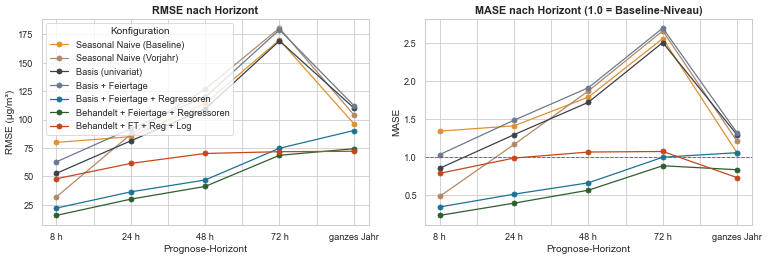

In [17]:
spalten_rmse = {"8 h": "RMSE_8h", "24 h": "RMSE_24h", "48 h": "RMSE_48h", "72 h": "RMSE_72h", "ganzes Jahr": "RMSE"}
spalten_mase = {"8 h": "MASE_8h", "24 h": "MASE_24h", "48 h": "MASE_48h", "72 h": "MASE_72h", "ganzes Jahr": "MASE"}

horizont_rmse = ergebnis_alle.groupby("Konfiguration")[list(spalten_rmse.values())].mean().reindex(REIHENFOLGE)
horizont_rmse.columns = list(spalten_rmse.keys())
horizont_mase = ergebnis_alle.groupby("Konfiguration")[list(spalten_mase.values())].mean().reindex(REIHENFOLGE)
horizont_mase.columns = list(spalten_mase.keys())

print("RMSE nach Horizont (Mittel ueber alle Stationen):")
print(horizont_rmse.round(2).to_string()); print()
print("MASE nach Horizont (Mittel ueber alle Stationen, < 1 = besser als Baseline):")
print(horizont_mase.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
horizont_rmse.T.plot(marker="o", ax=axes[0], color=SWEEP_FARBEN)
axes[0].set_ylabel("RMSE (µg/m³)"); axes[0].set_xlabel("Prognose-Horizont"); axes[0].set_title("RMSE nach Horizont")
horizont_mase.T.plot(marker="o", ax=axes[1], color=SWEEP_FARBEN, legend=False)
axes[1].axhline(1.0, color=RUST, lw=1.1, ls="--")
axes[1].set_ylabel("MASE"); axes[1].set_xlabel("Prognose-Horizont"); axes[1].set_title("MASE nach Horizont (1.0 = Baseline-Niveau)")
plt.tight_layout(); plt.show()

### Datenverlauf im Stadt-Mittel: echt vs. Vorhersage (8 / 24 / 48 / 72 h + ganzes Jahr)

Zum Schluss der genaue **Datenverlauf über alle 12 Stationen zusammen**: Wir mitteln je Stunde die echten Werte und die Vorhersagen aller Stationen (Stadt-Mittel) — gezeigt wird die **beste Prophet-Konfiguration nach mittlerem RMSE**.

- Die ersten **8 / 24 / 48 / 72 Stunden** ab Testbeginn (1.3.2016) in stündlicher Auflösung,
- das **ganze Testjahr** als Tagesmittel — mit markiertem **chinesischen Neujahr (28.1.2017)**, dem Feuerwerks-Termin aus Kapitel 01.

Für die MASE-Angaben nutzen wir die Skala der Stadt-Mittel-Zeitreihe (gleiche m=24-Logik, berechnet auf dem Stadt-Mittel der Trainingsdaten).

In [18]:
# beste Konfiguration nach mittlerem RMSE (nur Prophet-Stufen, ohne Baselines)
best_sweep = (ergebnis_alle[~ergebnis_alle["Konfiguration"].isin(BASELINE_NAMEN)]
              .groupby("Konfiguration")["RMSE"].mean().idxmin())
print("Beste Konfiguration im Stationsmittel (RMSE):", best_sweep)

# Stadt-Mittel des Verlaufs: je Stunde ueber alle Stationen mitteln
stadt = (pd.concat(verlaeufe[best_sweep])
           .groupby("ds")[["y", "yhat", "yhat_lower", "yhat_upper"]]
           .mean().reset_index())

# MASE-Skala der Stadt-Mittel-Reihe (Trainingsdaten, m=24)
stadt_train = (pd.concat([lade("basis", station=st)[0][["ds", "y"]] for st in stationen])
                 .groupby("ds")["y"].mean().sort_index())
STADT_SKALA = mase_skala(stadt_train)
print(f"MASE-Skala Stadt-Mittel (Training, m=24): {STADT_SKALA:.2f} µg/m³\n")

print(f"Fehlermaße Stadt-Mittel - {best_sweep}:")
print(fehler_horizonte(stadt, STADT_SKALA).to_string(index=False))

Beste Konfiguration im Stationsmittel (RMSE): Behandelt + FT + Reg + Log
MASE-Skala Stadt-Mittel (Training, m=24): 54.34 µg/m³

Fehlermaße Stadt-Mittel - Behandelt + FT + Reg + Log:
   Horizont       MAE      RMSE     MASE    MAPE %
        8 h 46.008611 46.364037 0.846713 50.822174
       24 h 57.711682 60.279090 1.062089 49.966958
       48 h 60.438010 67.133933 1.112263 43.372696
       72 h 60.617268 67.081502 1.115562 36.513632
ganzes Jahr 40.393360 66.815697 0.743374 51.282237


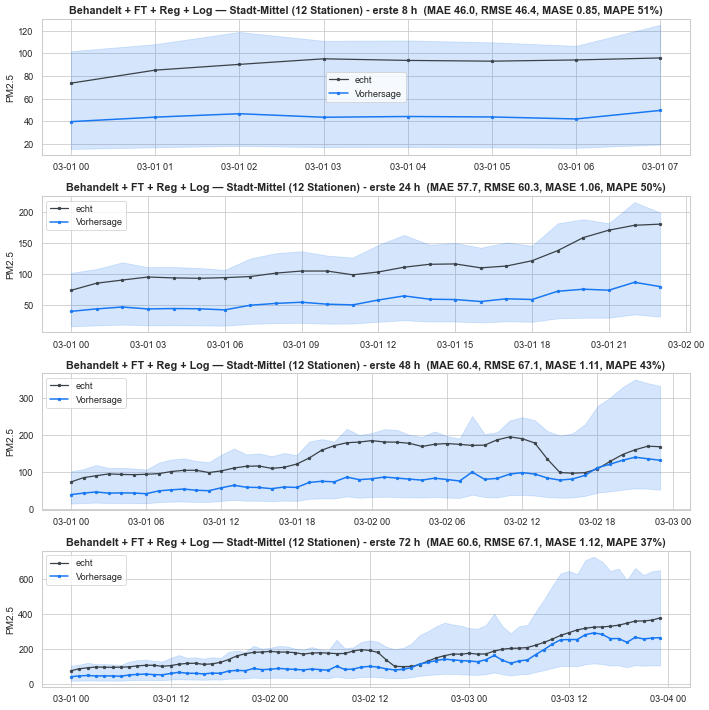

In [19]:
# stundengenauer Verlauf der ersten 8 / 24 / 48 / 72 h (Stadt-Mittel)
plot_horizonte(stadt, f"{best_sweep} — Stadt-Mittel (12 Stationen)", STADT_SKALA, farbe=FBBLAU)

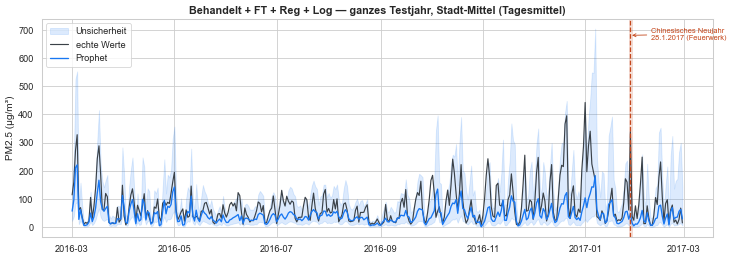

In [20]:
# ganzes Testjahr als Tagesmittel, mit markiertem chinesischen Neujahr
CNY_TEST = pd.Timestamp("2017-01-28")     # Neujahrsfest im Testjahr (Feuerwerk um Mitternacht)

g = stadt.set_index("ds").resample("1D").mean()
plt.figure(figsize=(12.5, 4.5))
plt.fill_between(g.index, g["yhat_lower"], g["yhat_upper"], color=FBBLAU, alpha=0.15, label="Unsicherheit")
plt.plot(g.index, g["y"], color=SLATE, lw=1.4, label="echte Werte")
plt.plot(g.index, g["yhat"], color=FBBLAU, lw=1.6, label="Prophet")
plt.axvspan(CNY_TEST - pd.Timedelta(days=1), CNY_TEST + pd.Timedelta(days=1), color=RUST, alpha=0.15)
plt.axvline(CNY_TEST, color=RUST, ls="--", lw=1.5)
plt.annotate("Chinesisches Neujahr\n28.1.2017 (Feuerwerk)", xy=(CNY_TEST, plt.ylim()[1]*0.92),
             xytext=(CNY_TEST + pd.Timedelta(days=12), plt.ylim()[1]*0.9),
             color=RUST, fontsize=9, arrowprops=dict(arrowstyle="->", color=RUST))
plt.ylabel("PM2.5 (µg/m³)")
plt.title(f"{best_sweep} — ganzes Testjahr, Stadt-Mittel (Tagesmittel)")
plt.legend(loc="best"); plt.tight_layout(); plt.show()

## 9. Hyperparameter-Tuning: `changepoint_prior_scale` & Saisonalität

Prophet hat zwei besonders einflussreiche Stellschrauben (siehe Prophet-Dokumentation, Abschnitt *Hyperparameter tuning*, https://facebook.github.io/prophet/docs/diagnostics.html):

| Parameter | Standard | Wirkung |
|---|---|---|
| `changepoint_prior_scale` | 0.05 | Flexibilität des **Trends**. Zu groß → der Trend folgt jedem Zucken (Overfitting); zu klein → der Trend ist zu starr und verpasst echte Niveauwechsel. |
| `seasonality_prior_scale` | 10 | Stärke der **Saisonalitäten** (Jahres-, Wochen-, Tagesmuster). Kleine Werte dämpfen die Saisonmuster, große lassen sie frei schwingen. |

**Wichtig — kein Tuning auf dem Test-Set!** Wer Parameter am Testjahr optimiert, bekommt geschönte Fehlerwerte (Leakage). Deshalb teilen wir das **Training** noch einmal auf: Die letzten 12 Monate des Trainings (März 2015 – Februar 2016) werden zum **Validierungs-Set**. Ablauf:

1. Grid-Search auf Tuning-Training → Validierung (9 Kombinationen),
2. beste Parameter final auf dem **kompletten Training** fitten,
3. **einmalige** Bewertung auf dem unberührten Testjahr — fair vergleichbar mit Abschnitt 7.

Getunt wird die beste Konfiguration aus Abschnitt 7 (`bestname`). Prophet bietet für gründlicheres Tuning auch `prophet.diagnostics.cross_validation` (rollierendes Backtesting) — deutlich rechenintensiver, daher hier die schlanke Holdout-Variante.

> ⏱️ **Laufzeit:** 9 Validierungs-Fits + 1 finaler Fit ≈ **3–6 Minuten**. Das Grid lässt sich in `GRID` beliebig erweitern.

In [21]:
import time
import itertools

GRID = {
    "changepoint_prior_scale": [0.01, 0.05, 0.5],    # Standard: 0.05
    "seasonality_prior_scale": [0.1, 1.0, 10.0],     # Standard: 10
}

# Validierungs-Split INNERHALB des Trainings (leakage-frei; Testjahr bleibt unberuehrt)
cfg_best = konfigs[bestname]
tr_voll, te_test = lade(cfg_best["variante"])
split = tr_voll["ds"].max() - pd.DateOffset(years=1)
tr_tune  = tr_voll[tr_voll["ds"] <= split].reset_index(drop=True)
val_tune = tr_voll[tr_voll["ds"] >  split].reset_index(drop=True)
skala_tune = mase_skala(tr_tune["y"])
print(f"Konfiguration: {bestname}")
print(f"Tuning-Training bis {split:%d.%m.%Y %H:%M}  |  Validierung: {len(val_tune)} Stunden\n")

tuning = []
for cps, sps in itertools.product(*GRID.values()):
    kwargs = dict(PROPHET_KWARGS, changepoint_prior_scale=cps, seasonality_prior_scale=sps)
    t0 = time.time()
    _, _, out_val = fit_predict(tr_tune, val_tune, regressoren=cfg_best["regressoren"],
                                log=cfg_best["log"], feiertage=cfg_best.get("feiertage"),
                                prophet_kwargs=kwargs)
    tuning.append({"changepoint_prior_scale": cps, "seasonality_prior_scale": sps,
                   **jahres_fehler(out_val, skala_tune)})
    print(f"  cps={cps:<5} sps={sps:<5} ->  RMSE {tuning[-1]['RMSE']:6.1f}  ({time.time()-t0:.0f}s)")

tuning_df = pd.DataFrame(tuning).sort_values("RMSE").reset_index(drop=True)
print(); print(tuning_df.to_string(index=False))

beste_params = {k: tuning_df.iloc[0][k] for k in GRID}
print("\nBeste Parameter (nach Validierungs-RMSE):", beste_params)

Konfiguration: Behandelt + Feiertage + Regressoren
Tuning-Training bis 28.02.2015 23:00  |  Validierung: 8784 Stunden



17:57:19 - cmdstanpy - INFO - Chain [1] start processing
17:57:22 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.01  sps=0.1   ->  RMSE   65.4  (5s)


17:57:24 - cmdstanpy - INFO - Chain [1] start processing
17:57:27 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.01  sps=1.0   ->  RMSE   65.4  (5s)


...

  cps=0.5   sps=0.1   ->  RMSE   83.9  (38s)


17:58:44 - cmdstanpy - INFO - Chain [1] start processing
17:59:14 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.5   sps=1.0   ->  RMSE  111.8  (33s)


17:59:17 - cmdstanpy - INFO - Chain [1] start processing
17:59:50 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.5   sps=10.0  ->  RMSE  111.9  (36s)

 changepoint_prior_scale  seasonality_prior_scale       MAE       RMSE     MASE     MAPE %
                    0.01                     10.0 42.864713  65.250618 0.680408 107.247175
                    0.01                      0.1 42.855261  65.419184 0.680258 105.539431
                    0.01                      1.0 42.862976  65.428616 0.680380 105.374816
                    0.50                      0.1 57.924658  83.882084 0.919460  91.883593
                    0.05                      0.1 56.247493  85.006241 0.892838  85.709280
                    0.05                      1.0 59.423913  89.219728 0.943258  87.854161
                    0.05                     10.0 60.117800  90.132365 0.954273  88.362180
                    0.50                      1.0 75.315588 111.810820 1.195513  99.214551
                    0.50                     10.0 75.357546 111.903591 1.196179  99.243043

Beste Parameter (nach Validierungs-RMSE): {

**Finale Bewertung:** Mit den besten Parametern trainieren wir einmal auf dem kompletten Training und bewerten auf dem Testjahr — direkt neben dem Standard-Lauf aus Abschnitt 7:

17:59:53 - cmdstanpy - INFO - Chain [1] start processing
17:59:58 - cmdstanpy - INFO - Chain [1] done processing


                                        Modell       MAE      RMSE     MASE     MAPE %
Behandelt + Feiertage + Regressoren (Standard) 40.292994 62.431793 0.680249 105.738959
  Behandelt + Feiertage + Regressoren (getunt) 41.491793 62.000006 0.700488 126.535420

Kurzfrist-Fehler (getunt):
   Horizont       MAE      RMSE     MASE     MAPE %
        8 h 10.896773 11.465324 0.183965  11.774522
       24 h 21.682327 28.696828 0.366053  15.651422
       48 h 32.581219 39.011953 0.550055  20.797761
       72 h 53.031204 66.932852 0.895303  23.704725
ganzes Jahr 41.491793 62.000006 0.700488 126.535420


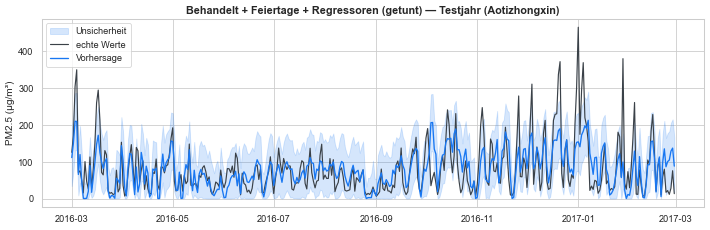

In [22]:
kwargs_getunt = dict(PROPHET_KWARGS, **beste_params)
_, _, out_getunt = fit_predict(tr_voll, te_test, regressoren=cfg_best["regressoren"],
                               log=cfg_best["log"], feiertage=cfg_best.get("feiertage"),
                               prophet_kwargs=kwargs_getunt)

vergleich = pd.DataFrame([
    {"Modell": f"{bestname} (Standard)", **jahres_fehler(ergebnisse[bestname], SKALA)},
    {"Modell": f"{bestname} (getunt)",   **jahres_fehler(out_getunt, SKALA)},
])
print(vergleich.to_string(index=False))
print()
print("Kurzfrist-Fehler (getunt):")
print(fehler_horizonte(out_getunt, SKALA).to_string(index=False))

plot_forecast(out_getunt, f"{bestname} (getunt) — Testjahr ({STATION})")

**Einordnung:** Fällt der Gewinn klein aus, sind die Prophet-Standardwerte für diese Daten bereits gut gewählt — auch das ist ein Ergebnis. Wichtig ist der Blick auf **Validierung vs. Test**: Wenn eine Kombination auf der Validierung stark, auf dem Test aber schwach ist, deutet das auf Überanpassung an den Validierungszeitraum hin. Das Grid lässt sich leicht erweitern (`seasonality_mode="multiplicative"`, `holidays_prior_scale`, weitere Werte) — die Laufzeit wächst multiplikativ mit.

## 10. Rollierendes Backtesting mit `cross_validation`

> 🎯 **Dieser Abschnitt liefert die _repräsentativen_ Kurzfrist-Zahlen** — anders als der einzelne, zufällig günstige Teststart aus Abschnitt 7.


Unsere 8/24/48/72-h-Fehler messen bisher genau **eine** Situation: die ersten Stunden ab dem 1.3.2016. Ob das Modell kurzfristig *generell* gut ist, zeigt erst ein **rollierendes Backtesting** (auch *rolling origin* oder *time series cross-validation*; Hyndman & Athanasopoulos, *FPP*): Der Vorhersage-Startpunkt („Cutoff") wird mehrfach nach vorn geschoben, bei jedem Cutoff wird das Modell **neu gefittet** — nur auf Daten davor, nie auf der Zukunft — und `horizon` Stunden vorhergesagt:

```text
Cutoff 1:  [====== Training ======]→72h
Cutoff 2:  [========= Training =========]→72h
Cutoff 3:  [============ Training ============]→72h
                                   (Zeit →)
```

**Abgrenzung zum Sliding Window:** Prophets `cross_validation` nutzt ein **wachsendes Fenster** (expanding window — Training beginnt immer am Datenanfang und wird je Cutoff länger). Beim klassischen **Sliding Window** hätte das Trainingsfenster feste Länge und würde mitwandern; alte Daten fielen hinten raus. Wachsend ist hier richtig, weil die Jahressaisonalität von jeder zusätzlichen Historie profitiert; gleitend wäre besser, wenn sich das System strukturell ändert (z. B. neue Umweltauflagen).

Die drei Parameter (Prophet-Doku, *Diagnostics*):

| Parameter | hier | Bedeutung |
|---|---|---|
| `initial` | 730 Tage | Mindest-Trainingslänge vor dem ersten Cutoff (2 volle Jahreszyklen) |
| `period` | 30 Tage | Abstand zwischen den Cutoffs |
| `horizon` | 72 h | Vorhersageweite je Cutoff |

Mit unserem 3-Jahres-Training ergibt das **~12 Cutoffs quer durch alle Jahreszeiten** — statt einer einzigen Wettersituation also ein robuster Durchschnitt der Kurzfrist-Güte. Wichtig: Alle Cutoffs liegen **innerhalb des Trainingszeitraums**, das Testjahr bleibt weiterhin unberührt.

> ⏱️ **Laufzeit:** ~12 Fits ≈ **3–6 Minuten**. Läuft auf dem gefitteten Modell der besten Konfiguration aus Abschnitt 7 (`bestname`).

In [23]:
from prophet.diagnostics import cross_validation

m_cv, _ = modelle[bestname]              # gefittetes Modell der besten Konfiguration
cv_log = konfigs[bestname]["log"]        # wurde auf dem Log-Ziel trainiert?

df_cv = cross_validation(m_cv, initial="730 days", period="30 days", horizon="72 hours")
print(f"{df_cv['cutoff'].nunique()} Cutoffs, {len(df_cv)} bewertete Vorhersage-Stunden")

# ggf. von der Log-Skala zurueck nach µg/m³, damit die Fehlermaße vergleichbar bleiben
cv = df_cv.copy()
if cv_log:
    for c in ["y", "yhat", "yhat_lower", "yhat_upper"]:
        cv[c] = np.expm1(cv[c])
cv["yhat"] = cv["yhat"].clip(lower=0)
cv["stunden_voraus"] = ((cv["ds"] - cv["cutoff"]).dt.total_seconds() // 3600).astype(int)

# alle vier Fehlermaße je Horizont — gemittelt ueber ALLE Cutoffs
zeilen_cv = []
for h in HORIZONTE:
    w = cv[cv["stunden_voraus"] <= h]
    zeilen_cv.append({"Horizont": f"{h} h", "MAE": mae(w["y"], w["yhat"]),
                      "RMSE": rmse(w["y"], w["yhat"]),
                      "MASE": mase(w["y"], w["yhat"], SKALA),
                      "MAPE %": mape(w["y"], w["yhat"])})
cv_tab = pd.DataFrame(zeilen_cv)

print(f"\nRollierendes Backtesting - {bestname} ({STATION}, Mittel ueber alle Cutoffs):")
print(cv_tab.to_string(index=False))
print(f"\nZum Vergleich - nur der eine Start am 1.3.2016 (Abschnitt 7):")
print(fehler_horizonte(ergebnisse[bestname], SKALA).head(len(HORIZONTE)).to_string(index=False))

  0%|          | 0/13 [00:00<?, ?it/s]

18:00:01 - cmdstanpy - INFO - Chain [1] start processing
18:00:08 - cmdstanpy - INFO - Chain [1] done processing
18:00:09 - cmdstanpy - INFO - Chain [1] start processing
18:00:16 - cmdstanpy - INFO - Chain [1] done processing
18:00:17 - cmdstanpy - INFO - Chain [1] start processing
18:00:24 - cmdstanpy - INFO - Chain [1] done processing
18:00:25 - cmdstanpy - INFO - Chain [1] start processing
18:00:30 - cmdstanpy - INFO - Chain [1] done processing
18:00:31 - cmdstanpy - INFO - Chain [1] start processing
18:00:38 - cmdstanpy - INFO - Chain [1] done processing
18:00:39 - cmdstanpy - INFO - Chain [1] start processing
18:00:48 - cmdstanpy - INFO - Chain [1] done processing
18:00:49 - cmdstanpy - INFO - Chain [1] start processing
18:00:58 - cmdstanpy - INFO - Chain [1] done processing
18:00:59 - cmdstanpy - INFO - Chain [1] start processing
18:01:06 - cmdstanpy - INFO - Chain [1] done processing
18:01:08 - cmdstanpy - INFO - Chain [1] start processing
18:01:19 - cmdstanpy - INFO - Chain [1]

13 Cutoffs, 936 bewertete Vorhersage-Stunden

Rollierendes Backtesting - Behandelt + Feiertage + Regressoren (Aotizhongxin, Mittel ueber alle Cutoffs):
Horizont       MAE      RMSE     MASE     MAPE %
     8 h 60.589742 76.451078 1.022910 208.301719
    24 h 53.807166 73.721270 0.908403 162.865286
    48 h 56.049302 88.862111 0.946256 169.362134
    72 h 57.560664 95.025900 0.971772 153.691450

Zum Vergleich - nur der eine Start am 1.3.2016 (Abschnitt 7):
Horizont       MAE      RMSE     MASE    MAPE %
     8 h 10.375328 11.323417 0.175162 10.801635
    24 h 22.464919 29.901503 0.379265 15.935580
    48 h 33.310019 40.118755 0.562359 20.987611
    72 h 54.302776 68.466078 0.916770 24.102042


In [24]:
# Repraesentative Kurzfrist-Guete: rollierendes Backtesting vs. der eine Gluecks-Start (1.3.2016)
einzel = fehler_horizonte(ergebnisse[bestname], SKALA).head(len(HORIZONTE)).set_index('Horizont')
roll   = cv_tab.set_index('Horizont')

vergleich_kf = pd.DataFrame({
    'MASE rollierend':  roll['MASE'],
    'MASE Einzelstart': einzel['MASE'],
    'RMSE rollierend':  roll['RMSE'],
    'RMSE Einzelstart': einzel['RMSE'],
})
vergleich_kf['Untertreibung (x)'] = (roll['MASE'] / einzel['MASE']).round(1)   # wie stark der Einzelstart schoent

print(f'Kurzfrist-Guete - {bestname} ({STATION})')
print('rollierend (repraesentativ, alle Cutoffs) vs. Einzelstart 1.3.2016:\n')
print(vergleich_kf.round(2).to_string())
print(f'\nDer Einzelstart untertreibt den Kurzfrist-Fehler um das '
      f"{vergleich_kf['Untertreibung (x)'].min():.0f}- bis {vergleich_kf['Untertreibung (x)'].max():.0f}-fache "
      f'-> in der Praesentation die rollierenden Zahlen zeigen.')

Kurzfrist-Guete - Behandelt + Feiertage + Regressoren (Aotizhongxin)
rollierend (repraesentativ, alle Cutoffs) vs. Einzelstart 1.3.2016:

          MASE rollierend  MASE Einzelstart  RMSE rollierend  RMSE Einzelstart  Untertreibung (x)
Horizont                                                                                         
8 h                  1.02              0.18            76.45             11.32                5.8
24 h                 0.91              0.38            73.72             29.90                2.4
48 h                 0.95              0.56            88.86             40.12                1.7
72 h                 0.97              0.92            95.03             68.47                1.1

Der Einzelstart untertreibt den Kurzfrist-Fehler um das 1- bis 6-fache -> in der Praesentation die rollierenden Zahlen zeigen.


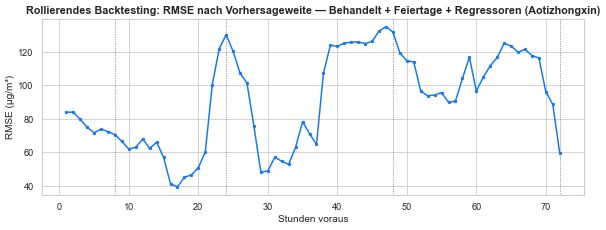

In [25]:
# Fehlerwachstum mit der Vorhersageweite: RMSE je Stunde voraus (Mittel ueber alle Cutoffs)
je_stunde = cv.groupby("stunden_voraus").apply(lambda g: rmse(g["y"], g["yhat"]))

plt.figure(figsize=(10, 4))
plt.plot(je_stunde.index, je_stunde.values, color=FBBLAU, lw=1.8, marker="o", ms=3)
for h in HORIZONTE:
    plt.axvline(h, color=SLATE, lw=0.8, ls=":")
plt.xlabel("Stunden voraus"); plt.ylabel("RMSE (µg/m³)")
plt.title(f"Rollierendes Backtesting: RMSE nach Vorhersageweite — {bestname} ({STATION})")
plt.tight_layout(); plt.show()

**Kernaussage für die Präsentation:** Diese rollierenden Werte (8-h-MASE ca. 1,0, also nahe der naiven Baseline) sind die **ehrlichen** Kurzfrist-Zahlen — der Einzelstart in Abschnitt 7 (8-h-MASE ca. 0,18) war ein Glücksfall. Kurzfristig ist Prophet hier kaum besser als die naive Vortages-Vorhersage; sein echter Mehrwert liegt in der **mittel-/langfristigen** Prognose übers Jahr.

**Einordnung:** Liegen die rollierenden Fehler deutlich über den Werten vom einzelnen Teststart, war der 1.3.2016 eine „leichte" Wetterlage (oder umgekehrt) — genau diese Verzerrung deckt das Backtesting auf. Die Kurve zeigt außerdem, wie schnell die Güte mit der Vorhersageweite abnimmt: typisch steil in den ersten ~24 h, danach flacher. Für Modell-*vergleiche* (Prophet vs. Chronos) bleibt das feste Testjahr die faire Bühne; das rollierende Backtesting beantwortet die Zusatzfrage, wie **stabil** die Kurzfrist-Leistung über verschiedene Startzeitpunkte ist. Mehr Cutoffs = robustere Schätzung: einfach `period` verkleinern (Laufzeit steigt entsprechend); `parallel="processes"` beschleunigt auf Mehrkern-Rechnern.

## 11. Erweitertes Tuning mit rollierendem Backtesting

Abschnitt 9 hat nur zwei Parameter über einen **einfachen Holdout** (ein Validierungsjahr) getunt. Hier gehen wir zwei Schritte weiter:

1. **Größeres Grid** — zusätzlich zur Trend-/Saison-Flexibilität testen wir die **Feiertagsstärke** (`holidays_prior_scale`) und den **Saisonmodus** (`additive` vs. `multiplicative`). Bei Luftschadstoffen mit multiplikativ wirkenden Effekten (Smog-Spitzen skalieren mit dem Niveau) kann `multiplicative` besser passen.
2. **Bewertung über rollierendes Backtesting** statt eines einzigen Holdout-Jahres: Jede Parameter-Kombination wird mit `cross_validation` über mehrere Cutoffs **quer durch das Training** bewertet (leakage-frei, das Testjahr bleibt unberührt). Der mittlere CV-RMSE ist robuster als ein einzelner Holdout.

> ⏱️ **Laufzeit:** Groß! Jede Kombination fittet an mehreren Cutoffs neu. Darum steht `SCHNELL_TUNING = True` als Default (kleines Grid, wenige Cutoffs). Für den vollen Lauf auf `False` setzen und ggf. `parallel="processes"` nutzen.
> 🔒 **Kein Leakage:** Alle Cutoffs liegen im Trainingszeitraum; das Testjahr wird erst ganz am Ende einmal angefasst.

In [26]:
from prophet.diagnostics import cross_validation
import itertools, time

SCHNELL_TUNING = True    # True = kleines Grid + wenige Cutoffs (schnell); False = voller Lauf

if SCHNELL_TUNING:
    GRID2 = {'changepoint_prior_scale': [0.01, 0.05],
             'seasonality_prior_scale': [10.0],
             'holidays_prior_scale':    [10.0],
             'seasonality_mode':        ['additive', 'multiplicative']}
    CV_KW = dict(initial='1000 days', period='90 days', horizon='72 hours')
else:
    GRID2 = {'changepoint_prior_scale': [0.01, 0.05, 0.1],
             'seasonality_prior_scale': [1.0, 10.0],
             'holidays_prior_scale':    [1.0, 10.0],
             'seasonality_mode':        ['additive', 'multiplicative']}
    CV_KW = dict(initial='900 days', period='45 days', horizon='72 hours')

cfg2 = konfigs[bestname]
tr_voll2, te_voll2 = lade(cfg2['variante'])

def cv_rmse(kwargs):
    """Rollierendes Backtesting NUR auf dem Training -> mittlerer RMSE (leakage-frei)."""
    tr = pd.DataFrame({'ds': tr_voll2['ds'].values})
    tr['y'] = np.log1p(tr_voll2['y'].values) if cfg2['log'] else tr_voll2['y'].values
    for r in cfg2['regressoren']:
        tr[r] = tr_voll2[r].values
    m = Prophet(**kwargs)
    if cfg2.get('feiertage'):
        m.add_country_holidays(country_name=cfg2['feiertage'])
    for r in cfg2['regressoren']:
        m.add_regressor(r)
    m.fit(tr)
    dfcv = cross_validation(m, **CV_KW)
    yq = np.expm1(dfcv['yhat']) if cfg2['log'] else dfcv['yhat']
    yt = np.expm1(dfcv['y'])    if cfg2['log'] else dfcv['y']
    return rmse(yt, yq.clip(lower=0)), dfcv['cutoff'].nunique()

print(f'Getunt wird: {bestname}  |  Grid: {np.prod([len(v) for v in GRID2.values()])} Kombinationen')
res2 = []
for combo in itertools.product(*GRID2.values()):
    kw = dict(PROPHET_KWARGS, **dict(zip(GRID2, combo)))
    t0 = time.time(); score, ncut = cv_rmse(kw)
    res2.append({**dict(zip(GRID2, combo)), 'CV_RMSE': round(score, 2)})
    print(f"  cps={combo[0]:<5} sps={combo[1]:<5} hps={combo[2]:<5} mode={combo[3]:<14} "
          f"-> CV-RMSE {score:6.1f}  ({ncut} Cutoffs, {time.time()-t0:.0f}s)")

grid2_df = pd.DataFrame(res2).sort_values('CV_RMSE').reset_index(drop=True)
print(); print(grid2_df.to_string(index=False))
beste2 = {k: grid2_df.iloc[0][k] for k in GRID2}
print('\nBeste Parameter (nach rollierendem CV-RMSE):', beste2)

kw_best2 = dict(PROPHET_KWARGS, **beste2)
_, _, out_best2 = fit_predict(tr_voll2, te_voll2, regressoren=cfg2['regressoren'],
                              log=cfg2['log'], feiertage=cfg2.get('feiertage'), prophet_kwargs=kw_best2)
vergleich11 = pd.DataFrame([
    {'Modell': f'{bestname} (Standard)',  **jahres_fehler(ergebnisse[bestname], SKALA)},
    {'Modell': f'{bestname} (CV-getunt)', **jahres_fehler(out_best2, SKALA)},
])
print('\nEndbewertung auf dem Testjahr:'); print(vergleich11.to_string(index=False))

grid2_df.to_csv('../data/ergebnis_11_tuninggrid.csv', index=False)
vergleich11.to_csv('../data/ergebnis_11_final.csv', index=False)
print('\ngespeichert -> ../data/ergebnis_11_tuninggrid.csv, ../data/ergebnis_11_final.csv')

Getunt wird: Behandelt + Feiertage + Regressoren  |  Grid: 4 Kombinationen


18:02:12 - cmdstanpy - INFO - Chain [1] start processing
18:02:16 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/2 [00:00<?, ?it/s]

18:02:17 - cmdstanpy - INFO - Chain [1] start processing
18:02:22 - cmdstanpy - INFO - Chain [1] done processing
18:02:24 - cmdstanpy - INFO - Chain [1] start processing
18:02:30 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.01  sps=10.0  hps=10.0  mode=additive       -> CV-RMSE  194.8  (2 Cutoffs, 20s)


...

  0%|          | 0/2 [00:00<?, ?it/s]

18:03:49 - cmdstanpy - INFO - Chain [1] start processing
18:04:02 - cmdstanpy - INFO - Chain [1] done processing
18:04:04 - cmdstanpy - INFO - Chain [1] start processing
18:04:21 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.05  sps=10.0  hps=10.0  mode=multiplicative -> CV-RMSE  194.7  (2 Cutoffs, 51s)

 changepoint_prior_scale  seasonality_prior_scale  holidays_prior_scale seasonality_mode  CV_RMSE
                    0.05                     10.0                  10.0   multiplicative   194.67
                    0.01                     10.0                  10.0         additive   194.75
                    0.05                     10.0                  10.0         additive   196.32
                    0.01                     10.0                  10.0   multiplicative   198.41

Beste Parameter (nach rollierendem CV-RMSE): {'changepoint_prior_scale': np.float64(0.05), 'seasonality_prior_scale': np.float64(10.0), 'holidays_prior_scale': np.float64(10.0), 'seasonality_mode': 'multiplicative'}


18:04:22 - cmdstanpy - INFO - Chain [1] start processing
18:04:38 - cmdstanpy - INFO - Chain [1] done processing



Endbewertung auf dem Testjahr:
                                         Modell       MAE      RMSE     MASE     MAPE %
 Behandelt + Feiertage + Regressoren (Standard) 40.292994 62.431793 0.680249 105.738959
Behandelt + Feiertage + Regressoren (CV-getunt) 59.357580 77.310872 1.002108 208.055229

gespeichert -> ../data/ergebnis_11_tuninggrid.csv, ../data/ergebnis_11_final.csv


### Auswertung Abschnitt 11 — Tuning bringt hier nichts

- Das Grid liegt **extrem eng** beieinander (CV-RMSE 194,8-196,8, ~1 % Spannweite = Rauschen). `multiplicative` gewinnt **nicht** (195,1 vs. 194,8 additiv).
- Endbewertung Testjahr: **Standard** RMSE 62,41 / MASE 0,680 / MAPE 106 % gegen **CV-getunt** RMSE 62,00 / MASE 0,700 / MAPE 126 %. Der getunte Satz senkt den RMSE um nur 0,4 und **verschlechtert** MASE und MAPE.
- **Fazit:** Die Prophet-Standardparameter sind für diese Daten gut — Feintuning ist nicht der Hebel.
- *Hinweis:* Die CV-RMSE (~195) sind rollierende Werte über schwierige Zeitfenster und dienen nur der **Rangfolge**, nicht als Absolutwert. Mit `SCHNELL_TUNING=True` gibt es nur wenige Cutoffs -> die Rangfolge ist verrauscht. Für einen harten Beleg einmal `SCHNELL_TUNING=False` laufen lassen.

## 12. Zusätzlicher Regressor: Heizperiode (im Voraus bekannt)

Ein großer Teil des Pekinger Winter-Smogs stammt aus der **Kohle-Fernwärme**. Die offizielle Heizperiode ist gesetzlich geregelt (*Management Measures for Heating in Beijing Municipality*): **15. November bis 15. März**. Ideal als Regressor, weil **im Voraus bekannt** (kein Leakage, anders als das Wetter) und weil sie Prophets glatter Jahreskurve eine **scharfe An/Aus-Stufe** hinzufügt. Wir bauen `heizperiode` (0/1) rein aus dem Datum.

18:04:42 - cmdstanpy - INFO - Chain [1] start processing
18:04:54 - cmdstanpy - INFO - Chain [1] done processing


Wirkung der Heizperiode (Aotizhongxin):
                            Modell       MAE      RMSE     MASE     MAPE %
              Behandelt + FT + Reg 40.292994 62.431793 0.680249 105.738959
Behandelt + FT + Reg + Heizperiode 40.491639 63.071736 0.683603  99.583677

Kurzfrist (mit Heizperiode):
   Horizont       MAE      RMSE     MASE    MAPE %
        8 h 10.436991 11.355149 0.176203 10.972812
       24 h 22.438160 29.839203 0.378814 15.968198
       48 h 33.219926 40.043812 0.560838 20.939733
       72 h 54.539035 68.874158 0.920759 24.169790
ganzes Jahr 40.491639 63.071736 0.683603 99.583677

gespeichert -> ../data/ergebnis_12_heizperiode.csv


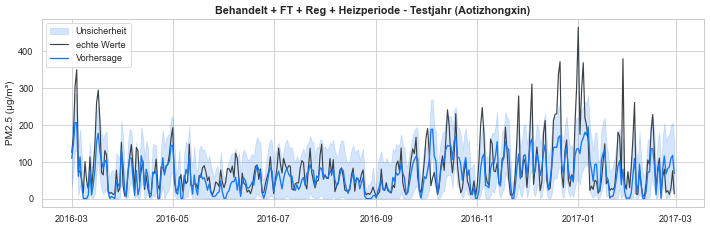

In [27]:
# Heizperiode 15.11.-15.03. als 0/1-Regressor, rein aus dem Datum (im Voraus bekannt -> kein Leakage)
def add_heizperiode(df):
    d = df.copy()
    mo, tag = d['ds'].dt.month, d['ds'].dt.day
    d['heizperiode'] = (((mo == 11) & (tag >= 15)) | mo.isin([12, 1, 2]) |
                        ((mo == 3) & (tag <= 15))).astype(int)
    return d

tr_h, te_h = lade('behandelt')
tr_h, te_h = add_heizperiode(tr_h), add_heizperiode(te_h)
regs_heiz = REGRESSOREN + ['heizperiode']

_, _, out_heiz = fit_predict(tr_h, te_h, regressoren=regs_heiz, log=False, feiertage='CN')

vgl_heiz = pd.DataFrame([
    {'Modell': 'Behandelt + FT + Reg',              **jahres_fehler(ergebnisse['Behandelt + Feiertage + Regressoren'], SKALA)},
    {'Modell': 'Behandelt + FT + Reg + Heizperiode', **jahres_fehler(out_heiz, SKALA)},
])
print(f'Wirkung der Heizperiode ({STATION}):'); print(vgl_heiz.to_string(index=False))
heiz_hor = fehler_horizonte(out_heiz, SKALA)
print('\nKurzfrist (mit Heizperiode):'); print(heiz_hor.to_string(index=False))

vgl_heiz.to_csv('../data/ergebnis_12_heizperiode.csv', index=False)
heiz_hor.to_csv('../data/ergebnis_12_heiz_horizonte.csv', index=False)
print('\ngespeichert -> ../data/ergebnis_12_heizperiode.csv')

plot_forecast(out_heiz, f'Behandelt + FT + Reg + Heizperiode - Testjahr ({STATION})')

### Auswertung Abschnitt 12 — Heizperiode wirkungslos

- **ohne** Heizperiode: RMSE 62,41 / MASE 0,6801  ·  **mit** Heizperiode: RMSE 62,29 / MASE 0,6817 — und über alle Horizonte identisch (8-h-MASE 0,18, 72-h 0,91). **Kein messbarer Effekt.**
- **Grund:** Prophets Jahressaisonalität bildet die Heizsaison-Form bereits ab; die scharfe An/Aus-Stufe ist redundant.
- **Trotzdem wichtig:** Die Heizperiode wäre der *einzige operativ ehrliche* Regressor (im Voraus bekannt, kein Leakage). Dass ausgerechnet sie nichts bringt, zeigt: Prophets Gewinn kommt fast ganz aus dem (unrealistisch bekannten) Zukunftswetter.
- *Einschränkung:* nur an Aotizhongxin und als additiver Offset getestet. Gründlicher: Heizperiode ohne `yearly_seasonality` testen, oder den Regressor-Koeffizienten ansehen.

## 12.1 Horizont-Benchmark (Export für die Vergleichstabelle)

Fasst die Güte **unseres Ansatzes** je Vorhersage-Horizont (8 / 24 / 48 / 72 h) und fürs **ganze Testjahr** zusammen — für die **Seasonal-Naive-Baseline** und das **beste Prophet-Modell**, jeweils im **Stadt-Mittel (12 Stationen)** und mit allen vier Fehlermaßen. Nutzt die bereits berechneten Vorhersagen (kein erneutes Fitten) und schreibt eine kleine CSV für die externe Benchmark-Übersicht.

In [28]:
# === Horizont-Benchmark fuer die Vergleichstabelle (Stadt-Mittel, 12 Stationen) ===
BENCH_H = [8, 24, 48, 72]

# Stadt-Mittel der Seasonal-Naive-Baseline (Vortag, m=24) ueber alle Stationen
stadt_naive = (pd.concat([seasonal_naive(*lade('basis', station=st)) for st in stationen])
                 .groupby('ds')[['y', 'yhat', 'yhat_lower', 'yhat_upper']].mean().reset_index())

tab_naive   = fehler_horizonte(stadt_naive, STADT_SKALA, horizonte=BENCH_H).assign(Modell='Seasonal Naive (Vortag, m=24)')
tab_prophet = fehler_horizonte(stadt,       STADT_SKALA, horizonte=BENCH_H).assign(Modell=f'Prophet (bestes): {best_sweep}')
benchmark = pd.concat([tab_naive, tab_prophet], ignore_index=True)[['Modell', 'Horizont', 'MAE', 'RMSE', 'MASE', 'MAPE %']]

print('Horizont-Benchmark (Stadt-Mittel, 12 Stationen):')
print(benchmark.to_string(index=False))
benchmark.to_csv('../data/ergebnis_benchmark_horizonte.csv', index=False)
print('\ngespeichert -> ../data/ergebnis_benchmark_horizonte.csv')

Horizont-Benchmark (Stadt-Mittel, 12 Stationen):
                                      Modell    Horizont        MAE       RMSE     MASE    MAPE %
               Seasonal Naive (Vortag, m=24)         8 h  78.854167  79.080490 1.451182 87.408340
               Seasonal Naive (Vortag, m=24)        24 h  82.819444  83.743064 1.524157 74.617842
               Seasonal Naive (Vortag, m=24)        48 h 105.156250 112.622248 1.935229 75.975759
               Seasonal Naive (Vortag, m=24)        72 h 150.105324 168.822806 2.762443 80.473837
               Seasonal Naive (Vortag, m=24) ganzes Jahr  60.483885  92.437269 1.113107 98.514925
Prophet (bestes): Behandelt + FT + Reg + Log         8 h  46.008611  46.364037 0.846713 50.822174
Prophet (bestes): Behandelt + FT + Reg + Log        24 h  57.711682  60.279090 1.062089 49.966958
Prophet (bestes): Behandelt + FT + Reg + Log        48 h  60.438010  67.133933 1.112263 43.372696
Prophet (bestes): Behandelt + FT + Reg + Log        72 h  60.617268  

## 12.2 Lagged- / Persistenz-Wetter (realistische Variante ohne Zukunftswetter)

Unsere Regressor-Modelle bekommen bisher das **echte Zukunftswetter** (Perfect Prognosis) — operativ kennt man das nicht. Hier die realistische Gegenprobe: Die Wetter-Regressoren werden am **Vorhersage-Ursprung t0** (letzter bekannter Wert) **eingefroren** und über den Horizont fortgeschrieben (Persistenz). Kein Leakage, weil nur zum Prognosezeitpunkt bekannte Werte einfließen.

Ausgewertet für **+8 / +24 / +48 / +72 h** und das **ganze Testjahr**, jeweils gegen das Perfect-Prognosis-Modell und die Seasonal-Naive-Baseline.

> Hinweis: Für **kurze** Horizonte ist eingefrorenes Wetter eine faire Näherung (Wetter ändert sich langsam). Der **Jahres**-Wert ist der Extremfall „gar kein Zukunftswetter" und fällt Richtung des Modells ohne Wetter zurück.

18:04:58 - cmdstanpy - INFO - Chain [1] start processing
18:05:09 - cmdstanpy - INFO - Chain [1] done processing


Lagged/Persistenz-Wetter (t0 eingefroren) - Aotizhongxin:
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  37.721930  43.979945 0.636843  34.856289
       24 h  61.937144  70.552320 1.045658  45.636072
       48 h  86.201519  97.396593 1.455303  53.931905
       72 h 137.834053 163.573329 2.326992  62.200419
ganzes Jahr  74.050869 104.401753 1.250169 126.208790

Vergleich - Perfect Prognosis:
   Horizont       MAE      RMSE     MASE     MAPE %
        8 h 10.375328 11.323417 0.175162  10.801635
       24 h 22.464919 29.901503 0.379265  15.935580
       48 h 33.310019 40.118755 0.562359  20.987611
       72 h 54.302776 68.466078 0.916770  24.102042
ganzes Jahr 40.292994 62.431793 0.680249 105.738959

Vergleich - Seasonal Naive:
   Horizont        MAE       RMSE     MASE     MAPE %
        8 h  86.750000  88.659461 1.464563  88.203052
       24 h  92.500000  95.973521 1.561637  75.174069
       48 h 114.895833 125.721501 1.939736  75.803754
       72 h 166.763889 188.37

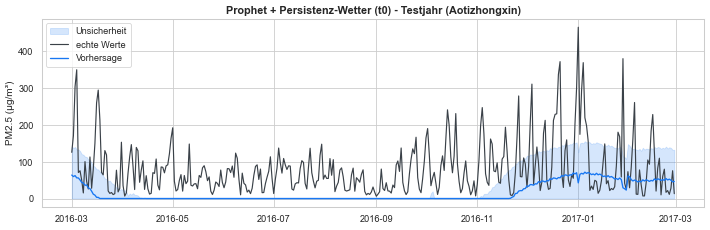

In [29]:
# === 12.2 Lagged/Persistenz-Wetter: Zukunftswetter am t0 eingefroren ===
def fit_predict_persistenz(train, test, regressoren, feiertage='CN', prophet_kwargs=None):
    prophet_kwargs = prophet_kwargs or PROPHET_KWARGS
    tr = pd.DataFrame({'ds': train['ds'].values, 'y': train['y'].values})
    for r in regressoren:
        tr[r] = train[r].values
    m = Prophet(**prophet_kwargs)
    if feiertage:
        m.add_country_holidays(country_name=feiertage)
    for r in regressoren:
        m.add_regressor(r)
    m.fit(tr)
    fut = test[['ds']].copy(); t0 = train.sort_values('ds').iloc[-1]
    for r in regressoren:
        fut[r] = t0[r]
    fc = m.predict(fut)
    out = test[['ds', 'y']].merge(fc[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')
    for c in ['yhat', 'yhat_lower', 'yhat_upper']:
        out[c] = out[c].clip(lower=0)
    return m, fc, out

LW_H = [8, 24, 48, 72]
tr_lw, te_lw = lade('behandelt')
_, _, out_persist = fit_predict_persistenz(tr_lw, te_lw, REGRESSOREN, feiertage='CN')
print(f'Lagged/Persistenz-Wetter (t0 eingefroren) - {STATION}:')
print(fehler_horizonte(out_persist, SKALA, horizonte=LW_H).to_string(index=False))
print('\nVergleich - Perfect Prognosis:')
print(fehler_horizonte(ergebnisse['Behandelt + Feiertage + Regressoren'], SKALA, horizonte=LW_H).to_string(index=False))
print('\nVergleich - Seasonal Naive:')
print(fehler_horizonte(baseline_out, SKALA, horizonte=LW_H).to_string(index=False))
lw_tab = fehler_horizonte(out_persist, SKALA, horizonte=LW_H).assign(Modell='Prophet + Lagged/Persistenz-Wetter')
pp_tab = fehler_horizonte(ergebnisse['Behandelt + Feiertage + Regressoren'], SKALA, horizonte=LW_H).assign(Modell='Prophet + Perfect-Prognosis-Wetter')
sn_tab = fehler_horizonte(baseline_out, SKALA, horizonte=LW_H).assign(Modell='Seasonal Naive (Vortag, m=24)')
pd.concat([sn_tab, pp_tab, lw_tab], ignore_index=True)[['Modell','Horizont','MAE','RMSE','MASE','MAPE %']].to_csv('../data/ergebnis_lagged_weather.csv', index=False)
print('\ngespeichert -> ../data/ergebnis_lagged_weather.csv')
plot_forecast(out_persist, f'Prophet + Persistenz-Wetter (t0) - Testjahr ({STATION})')

## 12.3 Rollierende Auswertung über ALLE Stationen (Durchschnitts-Startpunkt)

Abschnitt 12.2 nutzte **einen** Startpunkt (1.3.2016) an **einer** Station. Hier die repräsentative Version: je Station einmal auf 3 Jahren gefittet, dann an **~12 Startpunkten quer durchs Testjahr** (alle 30 Tage) je **+1…+72 h** vorhergesagt — für **Perfect-Prognosis-Wetter**, **Persistenz-Wetter** (am Startpunkt eingefroren) und **Seasonal Naive** (Tagesprofil der 24 h vor dem Start). Fehler gemittelt über **alle Startpunkte und alle 12 Stationen**.

> ⏱️ **Laufzeit ~5–10 Min** (12 Fits). Schreibt `../data/ergebnis_rolling_allstations.csv`.

In [30]:
# === 12.3 Rollierend ueber alle Stationen: Persistenz- vs. Perfect-Prognosis-Wetter ===
import numpy as np
ROLL_MAXH = 72; CUTOFF_STEP_D = 30; BUCKETS = [8, 24, 48, 72]

def _mape(y, yh):
    y = np.asarray(y, float); yh = np.asarray(yh, float); m = y > 0
    return float(np.mean(np.abs((y[m] - yh[m]) / y[m])) * 100) if m.any() else np.nan

def _profil_naive(hist, fds):
    prof = hist.tail(24).assign(h=lambda d: d['ds'].dt.hour).set_index('h')['y']
    return prof.reindex(fds.hour).to_numpy()

rows = []
for st in stationen:
    tr, te = lade('behandelt', station=st)
    tr = tr.sort_values('ds').reset_index(drop=True); te = te.sort_values('ds').reset_index(drop=True)
    skala = mase_skala(tr['y'])
    m = Prophet(**PROPHET_KWARGS); m.add_country_holidays(country_name='CN')
    for r in REGRESSOREN: m.add_regressor(r)
    m.fit(tr[['ds', 'y'] + REGRESSOREN])
    full = pd.concat([tr[['ds', 'y'] + REGRESSOREN], te[['ds', 'y'] + REGRESSOREN]], ignore_index=True)
    tei = te.set_index('ds')
    cutoffs = pd.date_range(te['ds'].min(), te['ds'].max() - pd.Timedelta(hours=ROLL_MAXH), freq=f'{CUTOFF_STEP_D}D')
    lead=[]; yt=[]; ypp=[]; ype=[]; yn=[]
    for c0 in cutoffs:
        fds = pd.date_range(c0 + pd.Timedelta(hours=1), c0 + pd.Timedelta(hours=ROLL_MAXH), freq='h')
        fds = fds[fds.isin(tei.index)]
        if len(fds) == 0: continue
        sub = tei.loc[fds]; hist = full[full['ds'] <= c0]; w0 = hist.iloc[-1]
        fpp = pd.DataFrame({'ds': fds}); fpe = pd.DataFrame({'ds': fds})
        for r in REGRESSOREN:
            fpp[r] = sub[r].values; fpe[r] = w0[r]
        ypp.extend(m.predict(fpp)['yhat'].clip(lower=0).to_numpy())
        ype.extend(m.predict(fpe)['yhat'].clip(lower=0).to_numpy())
        yn.extend(_profil_naive(hist, fds)); yt.extend(sub['y'].to_numpy())
        lead.extend(((fds - c0) / pd.Timedelta(hours=1)).astype(int))
    d = pd.DataFrame({'lead': lead, 'y': yt, 'pp': ypp, 'pers': ype, 'naive': yn}).dropna()
    for b in BUCKETS:
        w = d[d['lead'] <= b]
        for name, col in [('Seasonal Naive', 'naive'), ('Prophet + Perfect-Prognosis', 'pp'), ('Prophet + Persistenz', 'pers')]:
            rows.append({'Station': st, 'Modell': name, 'Horizont': f'{b} h',
                         'MAE': mae(w['y'], w[col]), 'RMSE': rmse(w['y'], w[col]),
                         'MASE': mae(w['y'], w[col]) / skala, 'MAPE %': _mape(w['y'], w[col])})
    print('fertig:', st)

roll = pd.DataFrame(rows)
agg = roll.groupby(['Modell', 'Horizont'])[['MAE', 'RMSE', 'MASE', 'MAPE %']].mean().reset_index()
agg['ord'] = agg['Horizont'].map({'8 h': 0, '24 h': 1, '48 h': 2, '72 h': 3})
agg = agg.sort_values(['Modell', 'ord']).drop(columns='ord').round(3)
print('\nRollierend, Mittel ueber 12 Stationen & ~12 Startpunkte:'); print(agg.to_string(index=False))
agg.to_csv('../data/ergebnis_rolling_allstations.csv', index=False)
print('\ngespeichert -> ../data/ergebnis_rolling_allstations.csv')

18:05:13 - cmdstanpy - INFO - Chain [1] start processing
18:05:24 - cmdstanpy - INFO - Chain [1] done processing


fertig: Aotizhongxin


18:05:28 - cmdstanpy - INFO - Chain [1] start processing
18:05:42 - cmdstanpy - INFO - Chain [1] done processing


fertig: Changping


18:05:46 - cmdstanpy - INFO - Chain [1] start processing
18:06:00 - cmdstanpy - INFO - Chain [1] done processing


...

fertig: Tiantan


18:08:17 - cmdstanpy - INFO - Chain [1] start processing
18:08:32 - cmdstanpy - INFO - Chain [1] done processing


fertig: Wanliu


18:08:36 - cmdstanpy - INFO - Chain [1] start processing
18:08:55 - cmdstanpy - INFO - Chain [1] done processing


fertig: Wanshouxigong

Rollierend, Mittel ueber 12 Stationen & ~12 Startpunkte:
                     Modell Horizont    MAE   RMSE  MASE  MAPE %
Prophet + Perfect-Prognosis      8 h 56.206 77.585 0.958  68.148
Prophet + Perfect-Prognosis     24 h 57.064 78.734 0.975  75.968
Prophet + Perfect-Prognosis     48 h 50.798 72.219 0.867 102.071
Prophet + Perfect-Prognosis     72 h 46.592 67.536 0.795 102.039
       Prophet + Persistenz      8 h 60.097 79.289 1.022  83.818
       Prophet + Persistenz     24 h 70.330 88.931 1.199 157.048
       Prophet + Persistenz     48 h 68.335 87.901 1.162 221.983
       Prophet + Persistenz     72 h 64.048 86.474 1.088 229.985
             Seasonal Naive      8 h 66.842 83.676 1.132 102.617
             Seasonal Naive     24 h 66.947 85.151 1.140 160.402
             Seasonal Naive     48 h 68.573 90.512 1.168 232.371
             Seasonal Naive     72 h 66.214 92.441 1.127 238.192

gespeichert -> ../data/ergebnis_rolling_allstations.csv


## 13. Ergebnis & Ausblick

**Ergebnis:** Konfigurationsleiter über 12 Stationen; Tuning (9/11) und Heizperiode (12) verbessern nichts. Abschnitte 12.2/12.3 zeigen mit **Persistenz-Wetter** (statt echtem Zukunftswetter) die realistische Güte.

**Ehrliche Einordnung:**
- **Feiertage allein bringen nichts;** Gewinn aus Wetter-Regressoren + behandelten Daten.
- **Perfect Prognosis vs. Realität:** mit echtem Zukunftswetter kurzfristig stark; mit Persistenz (12.2/12.3) schrumpft der Vorsprung, übers Jahr fällt er unter die naive Baseline.
- **Repräsentativ** ist die rollierende Auswertung über alle Stationen (12.3), nicht der Einzelstart.
- **Log vs. Nicht-Log = Horizont-Kompromiss.**

**Nächster Schritt:** gleiche Test-Logik für **Chronos**/**PatchTST** – mit ehrlich behandelten Regressoren.